### Setting Personal Parameters

In [ ]:
# ============================================================
# STEP 1: Personal parameters and reproducibility setup
# ============================================================

import os
import json
import random
from pathlib import Path

import numpy as np
import torch
from google.colab import drive


# ------------------------------------------------------------
# 1. Mount Google Drive
# ------------------------------------------------------------

drive.mount("/content/drive")


# ------------------------------------------------------------
# 2. Project folders
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/DATA 266/Lab/Lab1/Task 2"
)

FOLDERS = {
    "config": PROJECT_ROOT / "config",
    "data_processed": PROJECT_ROOT / "data_processed",
    "checkpoints": PROJECT_ROOT / "checkpoints",
    "outputs": PROJECT_ROOT / "outputs",
    "logs": PROJECT_ROOT / "logs",
    "metrics": PROJECT_ROOT / "metrics",
}

for folder in FOLDERS.values():
    folder.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 3. Personal parameters
# ------------------------------------------------------------

SID4 = 5775
SEED = 5775
SLICE = 775
HP_ID = 3
CLS_A = 5
CLS_B = 7


# ------------------------------------------------------------
# 4. Reproducibility
# ------------------------------------------------------------

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# More reproducible GPU results
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ------------------------------------------------------------
# 5. Verify GPU
# ------------------------------------------------------------

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is not available. In Colab, select "
        "Runtime > Change runtime type > L4 GPU."
    )

device = torch.device("cuda")
gpu_name = torch.cuda.get_device_name(0)
gpu_memory_gb = (
    torch.cuda.get_device_properties(0).total_memory / 1024**3
)


# ------------------------------------------------------------
# 6. Save personal parameters to Drive
# ------------------------------------------------------------

personal_parameters = {
    "SID4": SID4,
    "SEED": SEED,
    "SLICE": SLICE,
    "HP_ID": HP_ID,
    "CLS_A": CLS_A,
    "CLS_B": CLS_B,
}

config_path = FOLDERS["config"] / "personal_parameters.json"

with open(config_path, "w") as file:
    json.dump(personal_parameters, file, indent=4)


# ------------------------------------------------------------
# 7. Display setup information
# ------------------------------------------------------------

print("Project root:", PROJECT_ROOT)
print("Parameters saved to:", config_path)
print("File exists:", config_path.exists())
print("Device:", device)
print("GPU:", gpu_name)
print("GPU memory:", round(gpu_memory_gb, 2), "GB")
print("Seed:", SEED)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/DATA 266/Lab/Lab1/Task 2
Parameters saved to: /content/drive/MyDrive/DATA 266/Lab/Lab1/Task 2/config/personal_parameters.json
File exists: True
Device: cuda
GPU: NVIDIA L4
GPU memory: 22.03 GB
Seed: 5775


### Creating a persistant log file

In [ ]:
# ============================================================
# STEP 2: Persistent logging setup
# ============================================================

import logging
from datetime import datetime
from zoneinfo import ZoneInfo

LOG_PATH = FOLDERS["logs"] / "run_log.txt"
LOG_TZ = ZoneInfo("America/Los_Angeles")


class LocalTimeFormatter(logging.Formatter):
    def formatTime(self, record, datefmt=None):
        log_time = datetime.fromtimestamp(
            record.created,
            tz=LOG_TZ
        )
        return log_time.strftime("%Y-%m-%d %H:%M:%S %Z")


# Create one logger for this task
logger = logging.getLogger("task2_sentiment")
logger.setLevel(logging.INFO)
logger.propagate = False

# Prevent duplicate messages if this cell is rerun
logger.handlers.clear()

formatter = LocalTimeFormatter(
    "%(asctime)s | %(levelname)s | %(message)s"
)

# Save logs to one Drive file
file_handler = logging.FileHandler(
    LOG_PATH,
    mode="a",
    encoding="utf-8"
)
file_handler.setFormatter(formatter)

# Also display logs in Colab
console_handler = logging.StreamHandler()
console_handler.setFormatter(formatter)

logger.addHandler(file_handler)
logger.addHandler(console_handler)


# Mark the beginning of the notebook run
logger.info("=" * 60)
logger.info("TASK 2 NOTEBOOK RUN STARTED")
logger.info("SID4: %s", SID4)
logger.info("SEED: %s", SEED)
logger.info("Device: %s", device)
logger.info("GPU: %s", gpu_name)
logger.info("GPU memory: %.2f GB", gpu_memory_gb)
logger.info("Project root: %s", PROJECT_ROOT)

print("Log file:", LOG_PATH)
print("File exists:", LOG_PATH.exists())

Log file: /content/drive/MyDrive/DATA 266/Lab/Lab1/Task 2/logs/run_log.txt
File exists: True


### Downloading Dataset

In [ ]:
# ============================================================
# STEP 3: Load and save the raw Yelp Polarity dataset
# ============================================================

from datasets import load_dataset

RAW_DATA_DIR = FOLDERS["data_processed"] / "raw"
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_RAW_PATH = RAW_DATA_DIR / "train_raw.parquet"
TEST_RAW_PATH = RAW_DATA_DIR / "test_raw.parquet"


# Load saved Parquet files when available
if TRAIN_RAW_PATH.exists() and TEST_RAW_PATH.exists():
    logger.info("Loading raw dataset from saved Parquet files.")

    dataset = load_dataset(
        "parquet",
        data_files={
            "train": str(TRAIN_RAW_PATH),
            "test": str(TEST_RAW_PATH),
        }
    )

else:
    logger.info("Downloading Yelp Polarity dataset.")

    dataset = load_dataset(
        "fancyzhx/yelp_polarity"
    )

    logger.info("Saving training split to Drive.")
    dataset["train"].to_parquet(
        str(TRAIN_RAW_PATH)
    )

    logger.info("Saving test split to Drive.")
    dataset["test"].to_parquet(
        str(TEST_RAW_PATH)
    )

    logger.info("Raw Parquet files saved successfully.")


# Display and record dataset information
logger.info("Training examples: %s", len(dataset["train"]))
logger.info("Test examples: %s", len(dataset["test"]))
logger.info("Dataset columns: %s", dataset["train"].column_names)
logger.info("Dataset features: %s", dataset["train"].features)

print(dataset)
print("\nExample:")
print(dataset["train"][0])

README.md:   0%|          | 0.00/8.93k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  256MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 17.7MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/38000 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 560000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 38000
    })
})

Example:
{'text': "Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply never answers the phone.  It usually takes 2 hours of repeated calling to get an answer.  Who has time for that or wants to deal with it?  I have run into this problem with many other doctors and I just don't get it.  You have office workers, you have patients with medical needs, why isn't anyone answering the phone?  It's incomprehensible and not work the aggravation.  It's with regret that I feel that I have to give Dr. Goldberg 2 stars.", 'label': 0}


### EDA

In [ ]:
# ============================================================
# STEP 4: Dataset quality and distribution analysis
# ============================================================

import json
import numpy as np
from tqdm.auto import tqdm

EDA_DIR = FOLDERS["outputs"] / "eda"
EDA_DIR.mkdir(parents=True, exist_ok=True)

EDA_SUMMARY_PATH = EDA_DIR / "eda_summary.json"
LENGTHS_PATH = EDA_DIR / "review_lengths.npz"


def analyze_split(split, split_name, batch_size=10_000):
    total_rows = len(split)

    lengths = np.empty(total_rows, dtype=np.int32)
    class_counts = {0: 0, 1: 0}

    missing_text = 0
    empty_text = 0
    malformed_text = 0
    invalid_labels = 0

    position = 0

    for start in tqdm(
        range(0, total_rows, batch_size),
        desc=f"Analyzing {split_name}"
    ):
        batch = split[start:start + batch_size]

        for text, label in zip(batch["text"], batch["label"]):
            # Check text quality
            if text is None:
                missing_text += 1
                word_count = 0

            elif not isinstance(text, str):
                malformed_text += 1
                word_count = 0

            elif not text.strip():
                empty_text += 1
                word_count = 0

            else:
                word_count = len(text.split())

            lengths[position] = word_count

            # Check label quality
            if label in (0, 1):
                class_counts[int(label)] += 1
            else:
                invalid_labels += 1

            position += 1

    summary = {
        "total_rows": total_rows,
        "class_counts": class_counts,
        "class_percentages": {
            str(label): round(count / total_rows * 100, 2)
            for label, count in class_counts.items()
        },
        "missing_text": missing_text,
        "empty_text": empty_text,
        "malformed_text": malformed_text,
        "invalid_labels": invalid_labels,
        "length_statistics": {
            "minimum": int(lengths.min()),
            "maximum": int(lengths.max()),
            "mean": round(float(lengths.mean()), 2),
            "median": float(np.percentile(lengths, 50)),
            "90th_percentile": float(np.percentile(lengths, 90)),
            "95th_percentile": float(np.percentile(lengths, 95)),
            "99th_percentile": float(np.percentile(lengths, 99)),
        }
    }

    return summary, lengths


train_summary, train_lengths = analyze_split(
    dataset["train"],
    "train"
)

test_summary, test_lengths = analyze_split(
    dataset["test"],
    "test"
)

eda_summary = {
    "train": train_summary,
    "test": test_summary,
}


# Save the summary to Drive
with open(EDA_SUMMARY_PATH, "w", encoding="utf-8") as file:
    json.dump(eda_summary, file, indent=4)


# Save review lengths to avoid calculating them again
np.savez_compressed(
    LENGTHS_PATH,
    train=train_lengths,
    test=test_lengths
)


logger.info("EDA summary saved to: %s", EDA_SUMMARY_PATH)
logger.info("Review lengths saved to: %s", LENGTHS_PATH)
logger.info("Train summary: %s", train_summary)
logger.info("Test summary: %s", test_summary)

print(json.dumps(eda_summary, indent=4))

Analyzing train:   0%|          | 0/56 [00:00<?, ?it/s]

Analyzing test:   0%|          | 0/4 [00:00<?, ?it/s]

{
    "train": {
        "total_rows": 560000,
        "class_counts": {
            "0": 280000,
            "1": 280000
        },
        "class_percentages": {
            "0": 50.0,
            "1": 50.0
        },
        "missing_text": 0,
        "empty_text": 0,
        "malformed_text": 0,
        "invalid_labels": 0,
        "length_statistics": {
            "minimum": 1,
            "maximum": 1052,
            "mean": 133.03,
            "median": 97.0,
            "90th_percentile": 282.0,
            "95th_percentile": 372.0,
            "99th_percentile": 608.0
        }
    },
    "test": {
        "total_rows": 38000,
        "class_counts": {
            "0": 19000,
            "1": 19000
        },
        "class_percentages": {
            "0": 50.0,
            "1": 50.0
        },
        "missing_text": 0,
        "empty_text": 0,
        "malformed_text": 0,
        "invalid_labels": 0,
        "length_statistics": {
            "minimum": 1,
            "maxi

**Data is perfectly balanced and clean.**

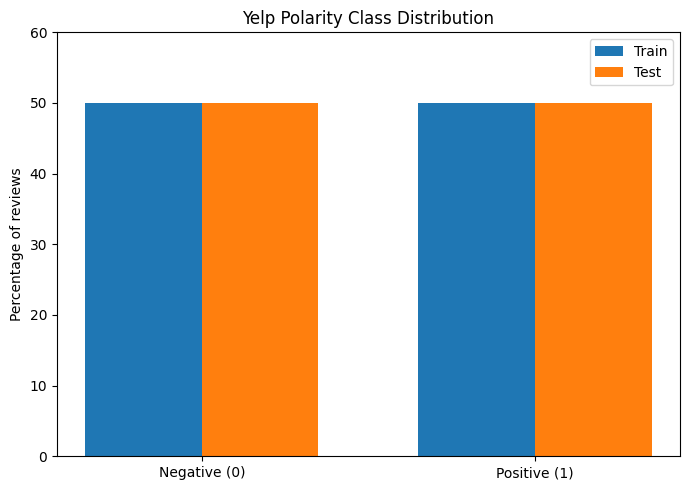

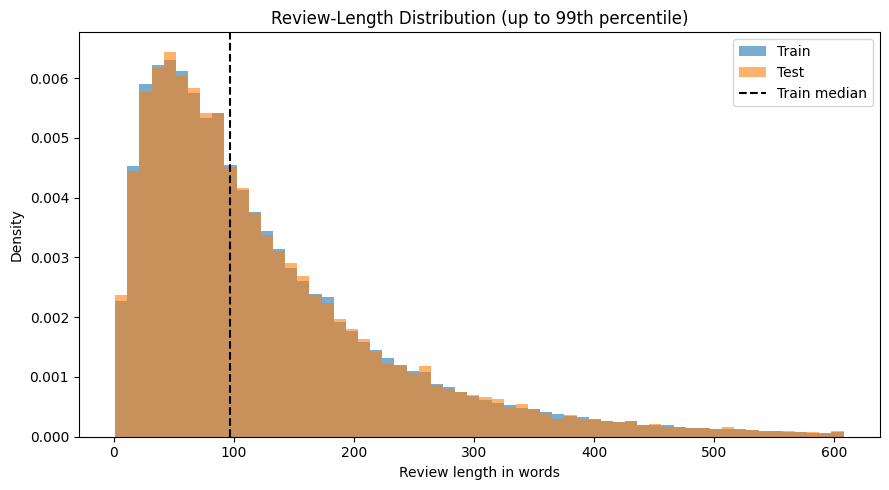

Saved: /content/drive/MyDrive/DATA 266/Lab/Lab1/Task 2/outputs/eda/class_distribution.png
Saved: /content/drive/MyDrive/DATA 266/Lab/Lab1/Task 2/outputs/eda/review_length_distribution.png


In [ ]:
# ============================================================
# STEP 5: Create and save EDA plots
# ============================================================

import json
import numpy as np
import matplotlib.pyplot as plt

# Reload saved results so this cell remains reusable
with open(EDA_SUMMARY_PATH, "r", encoding="utf-8") as file:
    saved_summary = json.load(file)

saved_lengths = np.load(LENGTHS_PATH)
train_lengths = saved_lengths["train"]
test_lengths = saved_lengths["test"]


# ------------------------------------------------------------
# 1. Class distribution plot
# ------------------------------------------------------------

labels = ["Negative (0)", "Positive (1)"]

train_percentages = [
    saved_summary["train"]["class_percentages"]["0"],
    saved_summary["train"]["class_percentages"]["1"],
]

test_percentages = [
    saved_summary["test"]["class_percentages"]["0"],
    saved_summary["test"]["class_percentages"]["1"],
]

x = np.arange(len(labels))
bar_width = 0.35

plt.figure(figsize=(7, 5))

plt.bar(
    x - bar_width / 2,
    train_percentages,
    width=bar_width,
    label="Train"
)

plt.bar(
    x + bar_width / 2,
    test_percentages,
    width=bar_width,
    label="Test"
)

plt.xticks(x, labels)
plt.ylabel("Percentage of reviews")
plt.title("Yelp Polarity Class Distribution")
plt.ylim(0, 60)
plt.legend()
plt.tight_layout()

CLASS_PLOT_PATH = EDA_DIR / "class_distribution.png"
plt.savefig(CLASS_PLOT_PATH, dpi=200, bbox_inches="tight")
plt.show()
plt.close()


# ------------------------------------------------------------
# 2. Review-length distribution
# ------------------------------------------------------------

# Limit the plot to the 99th percentile for readability
plot_limit = int(
    max(
        np.percentile(train_lengths, 99),
        np.percentile(test_lengths, 99)
    )
)

train_plot_lengths = train_lengths[
    train_lengths <= plot_limit
]

test_plot_lengths = test_lengths[
    test_lengths <= plot_limit
]

plt.figure(figsize=(9, 5))

plt.hist(
    train_plot_lengths,
    bins=60,
    density=True,
    alpha=0.6,
    label="Train"
)

plt.hist(
    test_plot_lengths,
    bins=60,
    density=True,
    alpha=0.6,
    label="Test"
)

plt.axvline(
    np.median(train_lengths),
    color="black",
    linestyle="--",
    label="Train median"
)

plt.xlabel("Review length in words")
plt.ylabel("Density")
plt.title("Review-Length Distribution (up to 99th percentile)")
plt.legend()
plt.tight_layout()

LENGTH_PLOT_PATH = EDA_DIR / "review_length_distribution.png"
plt.savefig(LENGTH_PLOT_PATH, dpi=200, bbox_inches="tight")
plt.show()
plt.close()


logger.info("Class distribution plot saved to: %s", CLASS_PLOT_PATH)
logger.info("Length distribution plot saved to: %s", LENGTH_PLOT_PATH)

print("Saved:", CLASS_PLOT_PATH)
print("Saved:", LENGTH_PLOT_PATH)

### Train - validation split

In [ ]:
# ============================================================
# STEP 6: Create reproducible stratified splits
# ============================================================

import numpy as np
from datasets import DatasetDict
from sklearn.model_selection import train_test_split

SPLIT_DIR = FOLDERS["data_processed"] / "split_information"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_INDEX_PATH = SPLIT_DIR / "split_indices.npz"


# ------------------------------------------------------------
# 1. Load existing indices or create new ones
# ------------------------------------------------------------

if SPLIT_INDEX_PATH.exists():
    logger.info("Loading previously saved split indices.")

    saved_indices = np.load(SPLIT_INDEX_PATH)

    train_indices = saved_indices["train_indices"]
    validation_indices = saved_indices["validation_indices"]

else:
    logger.info("Creating stratified train/validation split.")

    original_labels = np.asarray(
        dataset["train"]["label"],
        dtype=np.int8
    )

    all_indices = np.arange(
        len(dataset["train"]),
        dtype=np.int64
    )

    train_indices, validation_indices = train_test_split(
        all_indices,
        test_size=0.10,
        random_state=SEED,
        shuffle=True,
        stratify=original_labels
    )

    # Sorted indices provide faster access to the Arrow dataset
    train_indices = np.sort(train_indices)
    validation_indices = np.sort(validation_indices)

    np.savez_compressed(
        SPLIT_INDEX_PATH,
        train_indices=train_indices,
        validation_indices=validation_indices
    )

    logger.info("Split indices saved to: %s", SPLIT_INDEX_PATH)


# ------------------------------------------------------------
# 2. Create the dataset splits
# ------------------------------------------------------------

raw_splits = DatasetDict({
    "train": dataset["train"].select(train_indices),
    "validation": dataset["train"].select(validation_indices),
    "test": dataset["test"]
})


# ------------------------------------------------------------
# 3. Verify split sizes and class balance
# ------------------------------------------------------------

for split_name, split_data in raw_splits.items():
    labels = np.asarray(
        split_data["label"],
        dtype=np.int8
    )

    counts = np.bincount(labels, minlength=2)

    logger.info(
        "%s | rows=%s | negative=%s | positive=%s",
        split_name,
        len(split_data),
        counts[0],
        counts[1]
    )

    print(
        f"{split_name}: "
        f"{len(split_data):,} reviews | "
        f"negative={counts[0]:,} | "
        f"positive={counts[1]:,}"
    )

print("\nSplit indices saved to:", SPLIT_INDEX_PATH)

train: 504,000 reviews | negative=252,000 | positive=252,000
validation: 56,000 reviews | negative=28,000 | positive=28,000
test: 38,000 reviews | negative=19,000 | positive=19,000

Split indices saved to: /content/drive/MyDrive/DATA 266/Lab/Lab1/Task 2/data_processed/split_information/split_indices.npz


### Data Preparation

In [ ]:
import re
import html
import json
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [ ]:
# Preserve words that are important for sentiment
IMPORTANT_WORDS = {
    "no", "not", "nor", "never",
    "very", "too", "more", "most",
    "less", "least", "but", "against"
}

STOP_WORDS = set(ENGLISH_STOP_WORDS) - IMPORTANT_WORDS


def clean_text(text):
    """Clean one review while preserving sentiment information."""

    # Lowercase and decode HTML characters
    text = html.unescape(text.lower())

    # Remove HTML tags and newline markers
    text = re.sub(r"<[^>]+>", " ", text)
    text = text.replace("\\n", " ")

    # Preserve negation in contractions
    text = re.sub(r"\bwon['’]t\b", "will not", text)
    text = re.sub(r"\bcan['’]t\b", "can not", text)
    text = re.sub(r"n['’]t\b", " not", text)

    # Expand common contractions
    text = re.sub(r"['’]re\b", " are", text)
    text = re.sub(r"['’]ve\b", " have", text)
    text = re.sub(r"['’]ll\b", " will", text)
    text = re.sub(r"['’]m\b", " am", text)
    text = re.sub(r"['’]d\b", " would", text)
    text = re.sub(r"['’]s\b", " is", text)

    # Keep letters, numbers, and spaces
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Remove extra spaces and selected stopwords
    tokens = [
        word
        for word in text.split()
        if word not in STOP_WORDS
    ]

    return " ".join(tokens)


# Save preprocessing decisions
preprocessing_config = {
    "lowercase": True,
    "remove_html": True,
    "remove_punctuation": True,
    "keep_numbers": True,
    "remove_stopwords": True,
    "preserve_negations": sorted(IMPORTANT_WORDS),
    "stemming": False,
    "lemmatization": False,
}

PREPROCESSING_CONFIG_PATH = (
    FOLDERS["config"] / "preprocessing_config.json"
)

with open(
    PREPROCESSING_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(preprocessing_config, file, indent=4)


# Test the function on three reviews
for index in range(3):
    original = raw_splits["train"][index]["text"]
    cleaned = clean_text(original)

    print(f"\n--- Example {index + 1} ---")
    print("Original:")
    print(original[:500])

    print("\nCleaned:")
    print(cleaned[:500])

    print(
        "\nWord counts:",
        len(original.split()),
        "before →",
        len(cleaned.split()),
        "after"
    )


logger.info(
    "Preprocessing configuration saved to: %s",
    PREPROCESSING_CONFIG_PATH
)


--- Example 1 ---
Original:
Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply never answers the phone.  It usually takes 2 hours of repeated calling to get an answer.  Who has time for that or wants to deal with it?  I have run into this problem with many other doctors and I just don't get it.  You have office workers, you have patients with medical needs, why isn't anyone an

Cleaned:
unfortunately frustration dr goldberg patient repeat experience doctors nyc good doctor terrible staff staff simply never answers phone usually takes 2 hours repeated calling answer time wants deal run problem doctors just not office workers patients medical needs not answering phone incomprehensible not work aggravation regret feel dr goldberg 2 stars

Word counts: 115 before → 51 after

--- Example 2 ---
Original:
I don't know what Dr. Goldberg was like 

In [ ]:


import os
import gc
from datasets import load_dataset

CLEAN_DATA_DIR = FOLDERS["data_processed"] / "cleaned"
CLEAN_DATA_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_PATHS = {
    "train": CLEAN_DATA_DIR / "train_clean.parquet",
    "validation": CLEAN_DATA_DIR / "validation_clean.parquet",
    "test": CLEAN_DATA_DIR / "test_clean.parquet",
}

NUM_PROC = min(2, os.cpu_count() or 1)


def preprocess_batch(batch):
    cleaned_reviews = [
        clean_text(text)
        for text in batch["text"]
    ]

    word_counts = [
        len(text.split())
        for text in cleaned_reviews
    ]

    return {
        "clean_text": cleaned_reviews,
        "word_count": word_counts,
    }


for split_name, split_data in raw_splits.items():
    output_path = CLEAN_PATHS[split_name]

    if output_path.exists():
        logger.info(
            "%s already exists. Skipping preprocessing.",
            output_path
        )
        continue

    logger.info(
        "Preprocessing %s split with %s processes.",
        split_name,
        NUM_PROC
    )

    cleaned_split = split_data.map(
        preprocess_batch,
        batched=True,
        batch_size=1_000,
        num_proc=NUM_PROC,
        desc=f"Cleaning {split_name}",
        keep_in_memory=False
    )

    # Keep only processed text, label, and length
    cleaned_split = cleaned_split.remove_columns(["text"])
    cleaned_split = cleaned_split.rename_column(
        "clean_text",
        "text"
    )

    cleaned_split.to_parquet(str(output_path))

    logger.info(
        "%s split saved to: %s",
        split_name,
        output_path
    )

    # Release memory before processing the next split
    del cleaned_split
    gc.collect()


# Load the saved processed Parquet files
processed_splits = load_dataset(
    "parquet",
    data_files={
        split_name: str(path)
        for split_name, path in CLEAN_PATHS.items()
    }
)


# Verify processed data
for split_name, split_data in processed_splits.items():
    empty_count = sum(
        count == 0
        for count in split_data["word_count"]
    )

    logger.info(
        "%s | rows=%s | empty after cleaning=%s",
        split_name,
        len(split_data),
        empty_count
    )

    print(
        f"{split_name}: "
        f"{len(split_data):,} rows | "
        f"empty after cleaning={empty_count}"
    )

print("\nProcessed example:")
print(processed_splits["train"][0])

Cleaning train (num_proc=2):   0%|          | 0/504000 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

Cleaning validation (num_proc=2):   0%|          | 0/56000 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Cleaning test (num_proc=2):   0%|          | 0/38000 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

train: 504,000 rows | empty after cleaning=38
validation: 56,000 rows | empty after cleaning=2
test: 38,000 rows | empty after cleaning=1

Processed example:
{'label': 0, 'text': 'unfortunately frustration dr goldberg patient repeat experience doctors nyc good doctor terrible staff staff simply never answers phone usually takes 2 hours repeated calling answer time wants deal run problem doctors just not office workers patients medical needs not answering phone incomprehensible not work aggravation regret feel dr goldberg 2 stars', 'word_count': 51}


In [ ]:
## handling empty reviews and preserving rowID

import gc
from datasets import load_dataset

FINAL_DATA_DIR = FOLDERS["data_processed"] / "final_clean"
FINAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

FINAL_PATHS = {
    "train": FINAL_DATA_DIR / "train_final.parquet",
    "validation": FINAL_DATA_DIR / "validation_final.parquet",
    "test": FINAL_DATA_DIR / "test_final.parquet",
}

EMPTY_TOKEN = "<empty>"


def handle_empty_batch(batch, indices):
    updated_texts = []
    was_empty = []

    for text, word_count in zip(
        batch["text"],
        batch["word_count"]
    ):
        is_empty = word_count == 0

        if is_empty:
            updated_texts.append(EMPTY_TOKEN)
        else:
            updated_texts.append(text)

        was_empty.append(is_empty)

    return {
        "text": updated_texts,
        "row_id": indices,
        "was_empty": was_empty,
    }


for split_name, split_data in processed_splits.items():
    output_path = FINAL_PATHS[split_name]

    if output_path.exists():
        logger.info(
            "%s already exists. Skipping.",
            output_path
        )
        continue

    finalized_split = split_data.map(
        handle_empty_batch,
        batched=True,
        batch_size=1_000,
        with_indices=True,
        desc=f"Finalizing {split_name}"
    )

    finalized_split.to_parquet(str(output_path))

    logger.info(
        "Final %s data saved to: %s",
        split_name,
        output_path
    )

    del finalized_split
    gc.collect()


# Load final reusable model data
model_splits = load_dataset(
    "parquet",
    data_files={
        split_name: str(path)
        for split_name, path in FINAL_PATHS.items()
    }
)


# Verify final datasets
for split_name, split_data in model_splits.items():
    labels = np.asarray(
        split_data["label"],
        dtype=np.int8
    )

    class_counts = np.bincount(labels, minlength=2)
    replaced_count = sum(split_data["was_empty"])

    print(
        f"{split_name}: "
        f"{len(split_data):,} rows | "
        f"negative={class_counts[0]:,} | "
        f"positive={class_counts[1]:,} | "
        f"empty replaced={replaced_count}"
    )

    logger.info(
        "%s | rows=%s | negative=%s | positive=%s | "
        "empty replaced=%s",
        split_name,
        len(split_data),
        class_counts[0],
        class_counts[1],
        replaced_count
    )

Finalizing train:   0%|          | 0/504000 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

Finalizing validation:   0%|          | 0/56000 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Finalizing test:   0%|          | 0/38000 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

train: 504,000 rows | negative=252,000 | positive=252,000 | empty replaced=38
validation: 56,000 rows | negative=28,000 | positive=28,000 | empty replaced=2
test: 38,000 rows | negative=19,000 | positive=19,000 | empty replaced=1


### Building Vocabulary from Training data

In [ ]:
# ============================================================
# STEP 10: Build vocabulary from training data only
# ============================================================

import json
from collections import Counter
from tqdm.auto import tqdm

VOCAB_DIR = FOLDERS["data_processed"] / "vocabulary"
VOCAB_DIR.mkdir(parents=True, exist_ok=True)

VOCAB_PATH = VOCAB_DIR / "vocabulary.json"
VOCAB_STATS_PATH = VOCAB_DIR / "vocabulary_stats.json"

MAX_VOCAB_SIZE = 40_000
MIN_FREQUENCY = 2

SPECIAL_TOKENS = [
    "<pad>",
    "<unk>",
    "<empty>",
]


if VOCAB_PATH.exists() and VOCAB_STATS_PATH.exists():
    logger.info("Loading existing vocabulary.")

    with open(VOCAB_PATH, "r", encoding="utf-8") as file:
        word_to_idx = json.load(file)

    with open(VOCAB_STATS_PATH, "r", encoding="utf-8") as file:
        vocabulary_stats = json.load(file)

else:
    logger.info("Building vocabulary from training data.")

    token_counts = Counter()
    total_training_tokens = 0
    batch_size = 10_000

    train_data = model_splits["train"]

    for start in tqdm(
        range(0, len(train_data), batch_size),
        desc="Building vocabulary"
    ):
        batch = train_data[start:start + batch_size]

        for text in batch["text"]:
            tokens = text.split()
            token_counts.update(tokens)
            total_training_tokens += len(tokens)

    # Reserve the first indices for special tokens
    word_to_idx = {
        token: index
        for index, token in enumerate(SPECIAL_TOKENS)
    }

    for word, frequency in token_counts.most_common():
        if len(word_to_idx) >= MAX_VOCAB_SIZE:
            break

        if frequency < MIN_FREQUENCY:
            break

        if word not in word_to_idx:
            word_to_idx[word] = len(word_to_idx)

    included_words = set(word_to_idx) - set(SPECIAL_TOKENS)

    covered_tokens = sum(
        token_counts[word]
        for word in included_words
    )

    vocabulary_stats = {
        "maximum_vocabulary_size": MAX_VOCAB_SIZE,
        "actual_vocabulary_size": len(word_to_idx),
        "minimum_frequency": MIN_FREQUENCY,
        "unique_training_tokens": len(token_counts),
        "total_training_tokens": total_training_tokens,
        "covered_training_tokens": covered_tokens,
        "training_token_coverage_percent": round(
            covered_tokens / total_training_tokens * 100,
            2
        ),
        "special_tokens": SPECIAL_TOKENS,
    }

    with open(VOCAB_PATH, "w", encoding="utf-8") as file:
        json.dump(word_to_idx, file)

    with open(
        VOCAB_STATS_PATH,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(vocabulary_stats, file, indent=4)

    logger.info("Vocabulary saved to: %s", VOCAB_PATH)


idx_to_word = {
    index: word
    for word, index in word_to_idx.items()
}

PAD_IDX = word_to_idx["<pad>"]
UNK_IDX = word_to_idx["<unk>"]
EMPTY_IDX = word_to_idx["<empty>"]

VOCAB_SIZE = len(word_to_idx)

print(json.dumps(vocabulary_stats, indent=4))
print("\nPAD index:", PAD_IDX)
print("UNK index:", UNK_IDX)
print("EMPTY index:", EMPTY_IDX)
print("Final vocabulary size:", VOCAB_SIZE)

logger.info("Vocabulary statistics: %s", vocabulary_stats)

Building vocabulary:   0%|          | 0/51 [00:00<?, ?it/s]

{
    "maximum_vocabulary_size": 40000,
    "actual_vocabulary_size": 40000,
    "minimum_frequency": 2,
    "unique_training_tokens": 196532,
    "total_training_tokens": 32400291,
    "covered_training_tokens": 32054735,
    "training_token_coverage_percent": 98.93,
    "special_tokens": [
        "<pad>",
        "<unk>",
        "<empty>"
    ]
}

PAD index: 0
UNK index: 1
EMPTY index: 2
Final vocabulary size: 40000


**40,000 tokens cover 98.93% of all training tokensb**

### Measuring OOV rate and choosing sequence length

In [ ]:
# ============================================================
# STEP 11: Tokenization analysis
# ============================================================

import json
import math
import numpy as np
from tqdm.auto import tqdm

TOKEN_ANALYSIS_PATH = (
    FOLDERS["outputs"] / "eda" / "tokenization_analysis.json"
)

CANDIDATE_LENGTHS = [128, 192, 256, 320]


def analyze_tokens(split_data, split_name, batch_size=10_000):
    # Existing post-cleaning word counts
    lengths = np.asarray(
        split_data["word_count"],
        dtype=np.int32
    )

    # Empty reviews now contain the <empty> token
    lengths = np.maximum(lengths, 1)

    total_tokens = 0
    unknown_tokens = 0

    for batch in tqdm(
        split_data.iter(batch_size=batch_size),
        total=math.ceil(len(split_data) / batch_size),
        desc=f"Checking {split_name}"
    ):
        for text in batch["text"]:
            tokens = text.split()

            total_tokens += len(tokens)
            unknown_tokens += sum(
                token not in word_to_idx
                for token in tokens
            )

    length_comparison = {}

    for max_length in CANDIDATE_LENGTHS:
        reviews_fully_preserved = (
            lengths <= max_length
        ).mean() * 100

        tokens_preserved = (
            np.minimum(lengths, max_length).sum()
            / lengths.sum()
            * 100
        )

        length_comparison[str(max_length)] = {
            "reviews_fully_preserved_percent": round(
                float(reviews_fully_preserved), 2
            ),
            "tokens_preserved_percent": round(
                float(tokens_preserved), 2
            ),
        }

    return {
        "total_reviews": len(split_data),
        "total_tokens": int(total_tokens),
        "unknown_tokens": int(unknown_tokens),
        "oov_rate_percent": round(
            unknown_tokens / total_tokens * 100,
            2
        ),
        "length_statistics": {
            "mean": round(float(lengths.mean()), 2),
            "median": float(np.percentile(lengths, 50)),
            "90th_percentile": float(np.percentile(lengths, 90)),
            "95th_percentile": float(np.percentile(lengths, 95)),
            "99th_percentile": float(np.percentile(lengths, 99)),
            "maximum": int(lengths.max()),
        },
        "candidate_lengths": length_comparison,
    }


tokenization_analysis = {}

for split_name, split_data in model_splits.items():
    tokenization_analysis[split_name] = analyze_tokens(
        split_data,
        split_name
    )


with open(
    TOKEN_ANALYSIS_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(tokenization_analysis, file, indent=4)


logger.info(
    "Tokenization analysis saved to: %s",
    TOKEN_ANALYSIS_PATH
)

print(json.dumps(tokenization_analysis, indent=4))

Checking train:   0%|          | 0/51 [00:00<?, ?it/s]

Checking validation:   0%|          | 0/6 [00:00<?, ?it/s]

Checking test:   0%|          | 0/4 [00:00<?, ?it/s]

{
    "train": {
        "total_reviews": 504000,
        "total_tokens": 32400291,
        "unknown_tokens": 345518,
        "oov_rate_percent": 1.07,
        "length_statistics": {
            "mean": 64.29,
            "median": 47.0,
            "90th_percentile": 135.0,
            "95th_percentile": 178.0,
            "99th_percentile": 291.0,
            "maximum": 740
        },
        "candidate_lengths": {
            "128": {
                "reviews_fully_preserved_percent": 88.88,
                "tokens_preserved_percent": 88.78
            },
            "192": {
                "reviews_fully_preserved_percent": 96.02,
                "tokens_preserved_percent": 95.69
            },
            "256": {
                "reviews_fully_preserved_percent": 98.44,
                "tokens_preserved_percent": 98.26
            },
            "320": {
                "reviews_fully_preserved_percent": 99.31,
                "tokens_preserved_percent": 99.33
            }
    

- How often validation and test words become <unk>.
- How much of each review is retained at lengths 128, 192, 256, and 320.
- The best sequence length for training speed versus information retention.

max. sequence length = 256

In [ ]:
## Encode reviews as token IDs


import os
import gc
import json
from datasets import load_dataset

MAX_SEQUENCE_LENGTH = 256
NUM_PROC = min(2, os.cpu_count() or 1)

ENCODED_DATA_DIR = FOLDERS["data_processed"] / "encoded"
ENCODED_DATA_DIR.mkdir(parents=True, exist_ok=True)

ENCODED_PATHS = {
    "train": ENCODED_DATA_DIR / "train_encoded.parquet",
    "validation": ENCODED_DATA_DIR / "validation_encoded.parquet",
    "test": ENCODED_DATA_DIR / "test_encoded.parquet",
}


# ------------------------------------------------------------
# 1. Save encoding configuration
# ------------------------------------------------------------

encoding_config = {
    "vocabulary_size": VOCAB_SIZE,
    "maximum_sequence_length": MAX_SEQUENCE_LENGTH,
    "padding_index": PAD_IDX,
    "unknown_index": UNK_IDX,
    "empty_index": EMPTY_IDX,
    "padding_strategy": "dynamic batch padding",
    "truncation": "right truncation",
}

ENCODING_CONFIG_PATH = (
    FOLDERS["config"] / "encoding_config.json"
)

with open(
    ENCODING_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(encoding_config, file, indent=4)


# ------------------------------------------------------------
# 2. Encoding function
# ------------------------------------------------------------

def encode_batch(batch):
    encoded_reviews = []
    sequence_lengths = []

    for text in batch["text"]:
        token_ids = [
            word_to_idx.get(token, UNK_IDX)
            for token in text.split()
        ]

        # Truncate long reviews
        token_ids = token_ids[:MAX_SEQUENCE_LENGTH]

        # Safety check
        if not token_ids:
            token_ids = [EMPTY_IDX]

        encoded_reviews.append(token_ids)
        sequence_lengths.append(len(token_ids))

    return {
        "input_ids": encoded_reviews,
        "sequence_length": sequence_lengths,
    }


# ------------------------------------------------------------
# 3. Encode and save one split at a time
# ------------------------------------------------------------

for split_name, split_data in model_splits.items():
    output_path = ENCODED_PATHS[split_name]

    if output_path.exists():
        logger.info(
            "%s already exists. Skipping encoding.",
            output_path
        )
        continue

    logger.info("Encoding %s split.", split_name)

    encoded_split = split_data.map(
        encode_batch,
        batched=True,
        batch_size=1_000,
        num_proc=NUM_PROC,
        remove_columns=["text", "word_count"],
        desc=f"Encoding {split_name}",
        keep_in_memory=False
    )

    encoded_split.to_parquet(str(output_path))

    logger.info(
        "Encoded %s split saved to: %s",
        split_name,
        output_path
    )

    del encoded_split
    gc.collect()


# ------------------------------------------------------------
# 4. Load the reusable encoded data
# ------------------------------------------------------------

encoded_splits = load_dataset(
    "parquet",
    data_files={
        split_name: str(path)
        for split_name, path in ENCODED_PATHS.items()
    }
)


# ------------------------------------------------------------
# 5. Verify the encoded data
# ------------------------------------------------------------

for split_name, split_data in encoded_splits.items():
    lengths = np.asarray(
        split_data["sequence_length"],
        dtype=np.int32
    )

    print(
        f"{split_name}: "
        f"{len(split_data):,} rows | "
        f"minimum length={lengths.min()} | "
        f"maximum length={lengths.max()} | "
        f"mean length={lengths.mean():.2f}"
    )

print("\nEncoded example:")
print(encoded_splits["train"][0])

logger.info(
    "Encoding configuration saved to: %s",
    ENCODING_CONFIG_PATH
)

Encoding train (num_proc=2):   0%|          | 0/504000 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

Encoding validation (num_proc=2):   0%|          | 0/56000 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Encoding test (num_proc=2):   0%|          | 0/38000 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

train: 504,000 rows | minimum length=1 | maximum length=256 | mean length=63.17
validation: 56,000 rows | minimum length=1 | maximum length=256 | mean length=63.41
test: 38,000 rows | minimum length=1 | maximum length=256 | mean length=63.00

Encoded example:
{'label': 0, 'row_id': 0, 'was_empty': False, 'input_ids': [461, 3945, 676, 1, 1371, 1874, 49, 2754, 2316, 7, 1080, 290, 41, 41, 591, 20, 3431, 284, 237, 638, 29, 214, 3788, 1182, 1023, 13, 1418, 262, 383, 292, 2754, 9, 3, 452, 1101, 2900, 2590, 447, 3, 3919, 284, 23660, 3, 98, 10277, 1952, 125, 676, 1, 29, 114], 'sequence_length': 51}


### Creating Data Loader

In [ ]:

##Create PyTorch DataLoaders - using dynamic padding

import json
import random
import numpy as np
import torch

from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader


TRAIN_BATCH_SIZE = 256
EVAL_BATCH_SIZE = 512
NUM_WORKERS = 2


# ------------------------------------------------------------
# 1. Seed each DataLoader worker
# ------------------------------------------------------------

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)

    np.random.seed(worker_seed)
    random.seed(worker_seed)


data_generator = torch.Generator()
data_generator.manual_seed(SEED)


# ------------------------------------------------------------
# 2. Dynamic-padding collate function
# ------------------------------------------------------------

def collate_batch(batch):
    sequences = [
        torch.tensor(
            item["input_ids"],
            dtype=torch.long
        )
        for item in batch
    ]

    lengths = torch.tensor(
        [item["sequence_length"] for item in batch],
        dtype=torch.long
    )

    labels = torch.tensor(
        [item["label"] for item in batch],
        dtype=torch.float32
    )

    row_ids = torch.tensor(
        [item["row_id"] for item in batch],
        dtype=torch.long
    )

    padded_sequences = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=PAD_IDX
    )

    return {
        "input_ids": padded_sequences,
        "lengths": lengths,
        "labels": labels,
        "row_ids": row_ids,
    }


# ------------------------------------------------------------
# 3. Create DataLoaders
# ------------------------------------------------------------

train_loader = DataLoader(
    encoded_splits["train"],
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    worker_init_fn=seed_worker,
    generator=data_generator
)

validation_loader = DataLoader(
    encoded_splits["validation"],
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    encoded_splits["test"],
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)


# ------------------------------------------------------------
# 4. Save DataLoader configuration
# ------------------------------------------------------------

dataloader_config = {
    "train_batch_size": TRAIN_BATCH_SIZE,
    "evaluation_batch_size": EVAL_BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "dynamic_padding": True,
    "maximum_sequence_length": MAX_SEQUENCE_LENGTH,
    "shuffle_training_data": True,
}

DATALOADER_CONFIG_PATH = (
    FOLDERS["config"] / "dataloader_config.json"
)

with open(
    DATALOADER_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(dataloader_config, file, indent=4)


# ------------------------------------------------------------
# 5. Test one batch
# ------------------------------------------------------------

sample_batch = next(iter(train_loader))

print("Input shape:", sample_batch["input_ids"].shape)
print("Lengths shape:", sample_batch["lengths"].shape)
print("Labels shape:", sample_batch["labels"].shape)
print("Row IDs shape:", sample_batch["row_ids"].shape)

print(
    "Shortest sequence in batch:",
    sample_batch["lengths"].min().item()
)

print(
    "Longest sequence in batch:",
    sample_batch["lengths"].max().item()
)

print(
    "Padding index:",
    PAD_IDX
)

logger.info(
    "DataLoaders created: train batches=%s, "
    "validation batches=%s, test batches=%s",
    len(train_loader),
    len(validation_loader),
    len(test_loader)
)

logger.info(
    "DataLoader configuration saved to: %s",
    DATALOADER_CONFIG_PATH
)

del sample_batch

Input shape: torch.Size([256, 256])
Lengths shape: torch.Size([256])
Labels shape: torch.Size([256])
Row IDs shape: torch.Size([256])
Shortest sequence in batch: 4
Longest sequence in batch: 256
Padding index: 0


- Vocabulary: 40,000
- Embedding dimension: 128
- Hidden dimension: 128
- Maximum length: 256
- Embeddings learned from scratch
- Dropout: 0.30
- Same optimizer, learning rate, batch size, epochs, and early-stopping method

Whether GRU provides good performance with fewer recurrent parameters.
Whether bidirectional context improves sentiment detection.
Whether attention helps focus on important phrases such as “not worth it” or “very good.”

## Model Training

### 1). *Baseline GRU*

In [ ]:

import json
import torch
import torch.nn as nn

from torch.nn.utils.rnn import pack_padded_sequence


# Remove the earlier LSTM model if it was created
if "baseline_model" in globals():
    del baseline_model
    torch.cuda.empty_cache()


class BaselineGRU(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        padding_idx,
        dropout
    ):
        super().__init__()

        # Embeddings are randomly initialized and learned
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=padding_idx
        )

        self.embedding_dropout = nn.Dropout(dropout)

        # Single-layer, unidirectional GRU
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=False
        )

        self.output_dropout = nn.Dropout(dropout)

        # One output logit for binary classification
        self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)
        embedded = self.embedding_dropout(embedded)

        # Prevent the GRU from processing padding
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, hidden_state = self.gru(packed)

        # Shape: [batch_size, hidden_dim]
        final_hidden = hidden_state[-1]
        final_hidden = self.output_dropout(final_hidden)

        logits = self.classifier(final_hidden).squeeze(1)

        return logits


# ------------------------------------------------------------
# Model configuration
# ------------------------------------------------------------

baseline_gru_config = {
    "model_name": "baseline_gru",
    "model_role": "baseline",
    "vocabulary_size": VOCAB_SIZE,
    "embedding_dim": 128,
    "hidden_dim": 128,
    "num_layers": 1,
    "bidirectional": False,
    "dropout": 0.30,
    "embedding_source": "learned from scratch",
}

BASELINE_GRU_CONFIG_PATH = (
    FOLDERS["config"] / "baseline_gru_config.json"
)

with open(
    BASELINE_GRU_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(baseline_gru_config, file, indent=4)


# ------------------------------------------------------------
# Create model
# ------------------------------------------------------------

baseline_gru_model = BaselineGRU(
    vocab_size=VOCAB_SIZE,
    embedding_dim=baseline_gru_config["embedding_dim"],
    hidden_dim=baseline_gru_config["hidden_dim"],
    padding_idx=PAD_IDX,
    dropout=baseline_gru_config["dropout"]
).to(device)


# ------------------------------------------------------------
# Count parameters
# ------------------------------------------------------------

baseline_gru_parameter_count = sum(
    parameter.numel()
    for parameter in baseline_gru_model.parameters()
)

baseline_gru_trainable_parameters = sum(
    parameter.numel()
    for parameter in baseline_gru_model.parameters()
    if parameter.requires_grad
)


# ------------------------------------------------------------
# Test one forward pass
# ------------------------------------------------------------

test_batch = next(iter(train_loader))

test_input_ids = test_batch["input_ids"].to(
    device,
    non_blocking=True
)

test_lengths = test_batch["lengths"]

baseline_gru_model.eval()

with torch.no_grad():
    test_logits = baseline_gru_model(
        test_input_ids,
        test_lengths
    )


print(baseline_gru_model)
print("\nOutput shape:", test_logits.shape)
print(
    "Total parameters:",
    f"{baseline_gru_parameter_count:,}"
)
print(
    "Trainable parameters:",
    f"{baseline_gru_trainable_parameters:,}"
)


logger.info(
    "Baseline GRU created with %s trainable parameters.",
    baseline_gru_trainable_parameters
)

logger.info(
    "Baseline GRU configuration saved to: %s",
    BASELINE_GRU_CONFIG_PATH
)


del test_batch, test_input_ids, test_lengths, test_logits
torch.cuda.empty_cache()

BaselineGRU(
  (embedding): Embedding(40000, 128, padding_idx=0)
  (embedding_dropout): Dropout(p=0.3, inplace=False)
  (gru): GRU(128, 128, batch_first=True)
  (output_dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=1, bias=True)
)

Output shape: torch.Size([256])
Total parameters: 5,219,201
Trainable parameters: 5,219,201


In [ ]:
## smoke test
# ============================================================
# STEP 15: One-batch training smoke test
# ============================================================

import time
import torch
import torch.nn as nn


SMOKE_LEARNING_RATE = 1e-3
MAX_GRAD_NORM = 1.0


# Create a temporary model
smoke_model = BaselineGRU(
    vocab_size=VOCAB_SIZE,
    embedding_dim=baseline_gru_config["embedding_dim"],
    hidden_dim=baseline_gru_config["hidden_dim"],
    padding_idx=PAD_IDX,
    dropout=baseline_gru_config["dropout"]
).to(device)


criterion = nn.BCEWithLogitsLoss()

smoke_optimizer = torch.optim.AdamW(
    smoke_model.parameters(),
    lr=SMOKE_LEARNING_RATE,
    weight_decay=1e-4
)

scaler = torch.amp.GradScaler("cuda")


# Get one batch
smoke_batch = next(iter(train_loader))

input_ids = smoke_batch["input_ids"].to(
    device,
    non_blocking=True
)

lengths = smoke_batch["lengths"]

labels = smoke_batch["labels"].to(
    device,
    non_blocking=True
)


# Reset memory measurement
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()

start_time = time.perf_counter()

smoke_model.train()
smoke_optimizer.zero_grad(set_to_none=True)


# Mixed-precision forward pass
with torch.amp.autocast(
    device_type="cuda",
    dtype=torch.float16
):
    logits = smoke_model(input_ids, lengths)
    loss = criterion(logits, labels)


# Backward pass
scaler.scale(loss).backward()

# Unscale before gradient clipping
scaler.unscale_(smoke_optimizer)

gradient_norm = torch.nn.utils.clip_grad_norm_(
    smoke_model.parameters(),
    max_norm=MAX_GRAD_NORM
)

scaler.step(smoke_optimizer)
scaler.update()

torch.cuda.synchronize()

elapsed_time = time.perf_counter() - start_time
peak_memory_gb = (
    torch.cuda.max_memory_allocated() / 1024**3
)


# Verify output
print("Smoke-test loss:", round(loss.item(), 4))
print("Gradient norm:", round(gradient_norm.item(), 4))
print("Batch time:", round(elapsed_time, 3), "seconds")
print("Peak GPU memory:", round(peak_memory_gb, 3), "GB")
print("Logits shape:", logits.shape)

assert torch.isfinite(loss), "Loss is NaN or infinite."
assert torch.isfinite(gradient_norm), (
    "Gradient norm is NaN or infinite."
)

logger.info(
    "GRU smoke test passed | loss=%.4f | "
    "gradient_norm=%.4f | peak_memory=%.3f GB",
    loss.item(),
    gradient_norm.item(),
    peak_memory_gb
)


# Remove temporary smoke-test objects
del (
    smoke_model,
    smoke_optimizer,
    smoke_batch,
    input_ids,
    lengths,
    labels,
    logits,
    loss,
    scaler
)

torch.cuda.empty_cache()

Smoke-test loss: 0.7102
Gradient norm: 0.2095
Batch time: 1.054 seconds
Peak GPU memory: 0.146 GB
Logits shape: torch.Size([256])


In [ ]:
## training loop


import time
import torch
from tqdm.auto import tqdm


def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    scaler,
    epoch_number,
    max_grad_norm=1.0
):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    total_gradient_norm = 0.0
    completed_batches = 0
    nonfinite_count = 0

    torch.cuda.reset_peak_memory_stats()
    start_time = time.perf_counter()

    progress_bar = tqdm(
        data_loader,
        desc=f"Training epoch {epoch_number}"
    )

    for batch in progress_bar:
        input_ids = batch["input_ids"].to(
            device,
            non_blocking=True
        )

        lengths = batch["lengths"]

        labels = batch["labels"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

        if not torch.isfinite(loss).item():
            nonfinite_count += 1
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        gradient_norm = torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=max_grad_norm
        )

        if not torch.isfinite(gradient_norm).item():
            nonfinite_count += 1
            optimizer.zero_grad(set_to_none=True)
            scaler.update()
            continue

        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_correct += (
            (logits >= 0).float() == labels
        ).sum().item()

        total_examples += batch_size
        total_gradient_norm += gradient_norm.item()
        completed_batches += 1

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    torch.cuda.synchronize()
    elapsed_time = time.perf_counter() - start_time

    peak_memory_gb = (
        torch.cuda.max_memory_allocated() / 1024**3
    )

    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
        "average_gradient_norm": (
            total_gradient_norm / completed_batches
        ),
        "nonfinite_count": nonfinite_count,
        "examples_per_second": total_examples / elapsed_time,
        "epoch_time_seconds": elapsed_time,
        "peak_memory_gb": peak_memory_gb,
    }


@torch.no_grad()
def validate_one_epoch(
    model,
    data_loader,
    criterion,
    epoch_number
):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    start_time = time.perf_counter()

    progress_bar = tqdm(
        data_loader,
        desc=f"Validation epoch {epoch_number}"
    )

    for batch in progress_bar:
        input_ids = batch["input_ids"].to(
            device,
            non_blocking=True
        )

        lengths = batch["lengths"]

        labels = batch["labels"].to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_correct += (
            (logits >= 0).float() == labels
        ).sum().item()

        total_examples += batch_size

    torch.cuda.synchronize()
    elapsed_time = time.perf_counter() - start_time

    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
        "examples_per_second": total_examples / elapsed_time,
        "evaluation_time_seconds": elapsed_time,
    }


print("Training and validation functions created successfully.")

Training and validation functions created successfully.


In [ ]:
## training baseline GRU

# ============================================================
# STEP 17: Train baseline GRU
# ============================================================

import json
import random
import time
import numpy as np
import torch
import torch.nn as nn


# ------------------------------------------------------------
# 1. Training configuration
# ------------------------------------------------------------

MODEL_NAME = "baseline_gru"

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 6
EARLY_STOPPING_PATIENCE = 2
MINIMUM_IMPROVEMENT = 1e-4
MAX_GRAD_NORM = 1.0

GRU_CHECKPOINT_DIR = (
    FOLDERS["checkpoints"] / MODEL_NAME
)
GRU_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

GRU_OUTPUT_DIR = FOLDERS["outputs"] / MODEL_NAME
GRU_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEST_CHECKPOINT_PATH = (
    GRU_CHECKPOINT_DIR / "best_model.pt"
)

LATEST_CHECKPOINT_PATH = (
    GRU_CHECKPOINT_DIR / "latest_checkpoint.pt"
)

TRAINING_HISTORY_PATH = (
    GRU_OUTPUT_DIR / "training_history.json"
)

TRAINING_CONFIG_PATH = (
    FOLDERS["config"] / "baseline_gru_training_config.json"
)

training_config = {
    "model_name": MODEL_NAME,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "maximum_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "minimum_improvement": MINIMUM_IMPROVEMENT,
    "maximum_gradient_norm": MAX_GRAD_NORM,
    "optimizer": "AdamW",
    "loss": "BCEWithLogitsLoss",
    "scheduler": "ReduceLROnPlateau",
    "mixed_precision": "float16",
    "selection_metric": "validation_loss",
}

with open(
    TRAINING_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(training_config, file, indent=4)


# ------------------------------------------------------------
# 2. Reset seeds before official model initialization
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# 3. Create the official baseline model
# ------------------------------------------------------------

baseline_gru_model = BaselineGRU(
    vocab_size=VOCAB_SIZE,
    embedding_dim=baseline_gru_config["embedding_dim"],
    hidden_dim=baseline_gru_config["hidden_dim"],
    padding_idx=PAD_IDX,
    dropout=baseline_gru_config["dropout"]
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    baseline_gru_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

scaler = torch.amp.GradScaler("cuda")


# ------------------------------------------------------------
# 4. Initial training state
# ------------------------------------------------------------

start_epoch = 1
best_validation_loss = float("inf")
best_epoch = 0
patience_counter = 0
training_history = []


# Resume automatically if an interrupted run exists
if LATEST_CHECKPOINT_PATH.exists():
    logger.info(
        "Loading resumable checkpoint: %s",
        LATEST_CHECKPOINT_PATH
    )

    checkpoint = torch.load(
        LATEST_CHECKPOINT_PATH,
        map_location=device,
        weights_only=False
    )

    baseline_gru_model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    scheduler.load_state_dict(
        checkpoint["scheduler_state_dict"]
    )

    scaler.load_state_dict(
        checkpoint["scaler_state_dict"]
    )

    start_epoch = checkpoint["epoch"] + 1
    best_validation_loss = checkpoint["best_validation_loss"]
    best_epoch = checkpoint["best_epoch"]
    patience_counter = checkpoint["patience_counter"]
    training_history = checkpoint["training_history"]

    logger.info("Resuming from epoch %s.", start_epoch)


# ------------------------------------------------------------
# 5. Training loop
# ------------------------------------------------------------

logger.info("=" * 60)
logger.info("BASELINE GRU TRAINING STARTED")
logger.info("Starting epoch: %s", start_epoch)

full_training_start = time.perf_counter()

for epoch in range(start_epoch, MAX_EPOCHS + 1):
    current_learning_rate = optimizer.param_groups[0]["lr"]

    train_metrics = train_one_epoch(
        model=baseline_gru_model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        epoch_number=epoch,
        max_grad_norm=MAX_GRAD_NORM
    )

    validation_metrics = validate_one_epoch(
        model=baseline_gru_model,
        data_loader=validation_loader,
        criterion=criterion,
        epoch_number=epoch
    )

    scheduler.step(validation_metrics["loss"])

    epoch_record = {
        "epoch": epoch,
        "learning_rate": current_learning_rate,
        "train": train_metrics,
        "validation": validation_metrics,
    }

    training_history.append(epoch_record)

    improved = (
        validation_metrics["loss"]
        < best_validation_loss - MINIMUM_IMPROVEMENT
    )

    if improved:
        best_validation_loss = validation_metrics["loss"]
        best_epoch = epoch
        patience_counter = 0

        torch.save(
            {
                "epoch": epoch,
                "model_name": MODEL_NAME,
                "model_state_dict": (
                    baseline_gru_model.state_dict()
                ),
                "model_config": baseline_gru_config,
                "training_config": training_config,
                "validation_loss": best_validation_loss,
                "parameter_count": (
                    baseline_gru_trainable_parameters
                ),
            },
            BEST_CHECKPOINT_PATH
        )

        logger.info(
            "New best GRU checkpoint saved at epoch %s.",
            epoch
        )

    else:
        patience_counter += 1

    # Save checkpoint for recovery after interruption
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": (
                baseline_gru_model.state_dict()
            ),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_validation_loss": best_validation_loss,
            "best_epoch": best_epoch,
            "patience_counter": patience_counter,
            "training_history": training_history,
        },
        LATEST_CHECKPOINT_PATH
    )

    with open(
        TRAINING_HISTORY_PATH,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(
            {
                "model_name": MODEL_NAME,
                "best_epoch": best_epoch,
                "best_validation_loss": best_validation_loss,
                "epochs": training_history,
            },
            file,
            indent=4
        )

    logger.info(
        "Epoch %s/%s | "
        "train loss=%.4f | train accuracy=%.4f | "
        "validation loss=%.4f | validation accuracy=%.4f | "
        "gradient norm=%.4f | train examples/sec=%.2f | "
        "peak memory=%.3f GB | nonfinite=%s | lr=%.6f",
        epoch,
        MAX_EPOCHS,
        train_metrics["loss"],
        train_metrics["accuracy"],
        validation_metrics["loss"],
        validation_metrics["accuracy"],
        train_metrics["average_gradient_norm"],
        train_metrics["examples_per_second"],
        train_metrics["peak_memory_gb"],
        train_metrics["nonfinite_count"],
        current_learning_rate
    )

    print(
        f"Epoch {epoch}/{MAX_EPOCHS} | "
        f"train loss={train_metrics['loss']:.4f} | "
        f"train accuracy={train_metrics['accuracy']:.4f} | "
        f"val loss={validation_metrics['loss']:.4f} | "
        f"val accuracy={validation_metrics['accuracy']:.4f}"
    )

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        logger.info(
            "Early stopping triggered after epoch %s.",
            epoch
        )
        print("Early stopping triggered.")
        break


torch.cuda.synchronize()
full_training_time = (
    time.perf_counter() - full_training_start
)


# ------------------------------------------------------------
# 6. Reload the best model
# ------------------------------------------------------------

best_checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

baseline_gru_model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

logger.info(
    "Best GRU model loaded | epoch=%s | "
    "validation loss=%.4f | training session time=%.2f seconds",
    best_epoch,
    best_validation_loss,
    full_training_time
)

print("\nTraining complete.")
print("Best epoch:", best_epoch)
print(
    "Best validation loss:",
    round(best_validation_loss, 4)
)
print(
    "Current training-session time:",
    round(full_training_time, 2),
    "seconds"
)
print("Best checkpoint:", BEST_CHECKPOINT_PATH)

Training epoch 1:   0%|          | 0/1969 [00:00<?, ?it/s]

Validation epoch 1:   0%|          | 0/110 [00:00<?, ?it/s]

Epoch 1/6 | train loss=0.2474 | train accuracy=0.8974 | val loss=0.1745 | val accuracy=0.9327


Training epoch 2:   0%|          | 0/1969 [00:00<?, ?it/s]

Validation epoch 2:   0%|          | 0/110 [00:00<?, ?it/s]

...

Validation epoch 5:   0%|          | 0/110 [00:00<?, ?it/s]

Epoch 5/6 | train loss=0.1177 | train accuracy=0.9547 | val loss=0.1320 | val accuracy=0.9501


Training epoch 6:   0%|          | 0/1969 [00:00<?, ?it/s]

Validation epoch 6:   0%|          | 0/110 [00:00<?, ?it/s]

Epoch 6/6 | train loss=0.1099 | train accuracy=0.9581 | val loss=0.1388 | val accuracy=0.9508

Training complete.
Best epoch: 5
Best validation loss: 0.132
Current training-session time: 272.65 seconds
Best checkpoint: /content/drive/MyDrive/DATA 266/Lab/Lab1/Task 2/checkpoints/baseline_gru/best_model.pt


**Testing baseline GRU on test**

In [ ]:
# ============================================================
# STEP 18: Baseline GRU test inference
# ============================================================

import json
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from tqdm.auto import tqdm


BASELINE_PREDICTIONS_PATH = (
    GRU_OUTPUT_DIR / "test_predictions.parquet"
)

BASELINE_INFERENCE_PATH = (
    GRU_OUTPUT_DIR / "inference_summary.json"
)


@torch.no_grad()
def predict_model(model, data_loader, criterion):
    model.eval()

    all_logits = []
    all_labels = []
    all_row_ids = []

    total_loss = 0.0
    total_examples = 0

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

    start_time = time.perf_counter()

    for batch in tqdm(
        data_loader,
        desc="Testing baseline GRU"
    ):
        input_ids = batch["input_ids"].to(
            device,
            non_blocking=True
        )

        lengths = batch["lengths"]

        labels = batch["labels"].to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_examples += batch_size

        all_logits.append(
            logits.float().cpu()
        )

        all_labels.append(
            labels.cpu()
        )

        all_row_ids.append(
            batch["row_ids"].cpu()
        )

    torch.cuda.synchronize()

    inference_time = (
        time.perf_counter() - start_time
    )

    peak_memory_gb = (
        torch.cuda.max_memory_allocated() / 1024**3
    )

    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy().astype(int)
    row_ids = torch.cat(all_row_ids).numpy()

    probabilities = 1 / (1 + np.exp(-logits))
    predictions = (probabilities >= 0.5).astype(int)

    return {
        "row_ids": row_ids,
        "labels": labels,
        "logits": logits,
        "probabilities": probabilities,
        "predictions": predictions,
        "test_loss": total_loss / total_examples,
        "inference_time_seconds": inference_time,
        "examples_per_second": (
            total_examples / inference_time
        ),
        "peak_memory_gb": peak_memory_gb,
    }


# Run inference using the best checkpoint
criterion = nn.BCEWithLogitsLoss()

baseline_test_results = predict_model(
    baseline_gru_model,
    test_loader,
    criterion
)


# Save individual predictions
baseline_predictions = pd.DataFrame({
    "row_id": baseline_test_results["row_ids"],
    "label": baseline_test_results["labels"],
    "logit": baseline_test_results["logits"],
    "probability_positive": (
        baseline_test_results["probabilities"]
    ),
    "prediction": baseline_test_results["predictions"],
})

baseline_predictions["correct"] = (
    baseline_predictions["label"]
    == baseline_predictions["prediction"]
)

baseline_predictions.to_parquet(
    BASELINE_PREDICTIONS_PATH,
    index=False
)


# Save inference efficiency summary
baseline_inference_summary = {
    "model_name": MODEL_NAME,
    "test_loss": baseline_test_results["test_loss"],
    "inference_time_seconds": (
        baseline_test_results["inference_time_seconds"]
    ),
    "examples_per_second": (
        baseline_test_results["examples_per_second"]
    ),
    "peak_memory_gb": (
        baseline_test_results["peak_memory_gb"]
    ),
    "number_of_test_examples": len(
        baseline_predictions
    ),
}

with open(
    BASELINE_INFERENCE_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        baseline_inference_summary,
        file,
        indent=4
    )


preliminary_accuracy = (
    baseline_predictions["correct"].mean()
)

print(
    "Test loss:",
    round(baseline_test_results["test_loss"], 4)
)

print(
    "Preliminary test accuracy:",
    round(preliminary_accuracy, 4)
)

print(
    "Inference time:",
    round(
        baseline_test_results["inference_time_seconds"],
        2
    ),
    "seconds"
)

print(
    "Examples per second:",
    round(
        baseline_test_results["examples_per_second"],
        2
    )
)

print(
    "Peak GPU memory:",
    round(
        baseline_test_results["peak_memory_gb"],
        3
    ),
    "GB"
)

print(
    "Predictions saved to:",
    BASELINE_PREDICTIONS_PATH
)


logger.info(
    "Baseline GRU test inference complete | "
    "loss=%.4f | accuracy=%.4f | "
    "examples/sec=%.2f | peak memory=%.3f GB",
    baseline_test_results["test_loss"],
    preliminary_accuracy,
    baseline_test_results["examples_per_second"],
    baseline_test_results["peak_memory_gb"]
)

Testing baseline GRU:   0%|          | 0/75 [00:00<?, ?it/s]

Test loss: 0.127
Preliminary test accuracy: 0.9517
Inference time: 1.79 seconds
Examples per second: 21242.15
Peak GPU memory: 0.279 GB
Predictions saved to: /content/drive/MyDrive/DATA 266/Lab/Lab1/Task 2/outputs/baseline_gru/test_predictions.parquet


In [ ]:
## Calculating required metrics

# ============================================================
# STEP 19: Baseline GRU point-estimate metrics
# ============================================================

import json
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc,
    average_precision_score,
    matthews_corrcoef,
    brier_score_loss,
    classification_report,
)


# Reload predictions if necessary
baseline_predictions = pd.read_parquet(
    BASELINE_PREDICTIONS_PATH
)

y_true = baseline_predictions["label"].to_numpy()
y_pred = baseline_predictions["prediction"].to_numpy()
y_probability = baseline_predictions[
    "probability_positive"
].to_numpy()


# ------------------------------------------------------------
# 1. Accuracy, precision, recall, and F1
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

averaged_metrics = {}

for average_type in ["macro", "micro", "weighted"]:
    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average=average_type,
            zero_division=0
        )
    )

    averaged_metrics[average_type] = {
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
    }


# ------------------------------------------------------------
# 2. ROC-AUC and PR-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_true,
    y_probability
)

curve_precision, curve_recall, _ = (
    precision_recall_curve(
        y_true,
        y_probability
    )
)

pr_auc = auc(
    curve_recall,
    curve_precision
)

average_precision = average_precision_score(
    y_true,
    y_probability
)


# ------------------------------------------------------------
# 3. MCC, Brier score, and confusion matrix
# ------------------------------------------------------------

mcc = matthews_corrcoef(
    y_true,
    y_pred
)

brier_score = brier_score_loss(
    y_true,
    y_probability
)

confusion = confusion_matrix(
    y_true,
    y_pred
)


# ------------------------------------------------------------
# 4. Expected Calibration Error
# ------------------------------------------------------------

def expected_calibration_error(
    labels,
    probabilities,
    number_of_bins=15
):
    bin_edges = np.linspace(
        0.0,
        1.0,
        number_of_bins + 1
    )

    bin_ids = np.digitize(
        probabilities,
        bin_edges[1:-1],
        right=False
    )

    ece = 0.0
    reliability_rows = []

    for bin_index in range(number_of_bins):
        mask = bin_ids == bin_index
        bin_count = int(mask.sum())

        if bin_count == 0:
            continue

        mean_probability = float(
            probabilities[mask].mean()
        )

        observed_positive_rate = float(
            labels[mask].mean()
        )

        bin_weight = bin_count / len(labels)

        calibration_gap = abs(
            mean_probability
            - observed_positive_rate
        )

        ece += bin_weight * calibration_gap

        reliability_rows.append({
            "bin_lower": float(bin_edges[bin_index]),
            "bin_upper": float(
                bin_edges[bin_index + 1]
            ),
            "count": bin_count,
            "mean_probability": mean_probability,
            "observed_positive_rate": (
                observed_positive_rate
            ),
            "calibration_gap": calibration_gap,
        })

    return float(ece), reliability_rows


ece, reliability_rows = expected_calibration_error(
    y_true,
    y_probability,
    number_of_bins=15
)


# ------------------------------------------------------------
# 5. Training efficiency information
# ------------------------------------------------------------

total_train_seconds = sum(
    epoch["train"]["epoch_time_seconds"]
    for epoch in training_history
)

total_validation_seconds = sum(
    epoch["validation"]["evaluation_time_seconds"]
    for epoch in training_history
)

total_training_time = (
    total_train_seconds
    + total_validation_seconds
)

training_examples_per_second = (
    len(encoded_splits["train"])
    * len(training_history)
    / total_train_seconds
)

training_peak_memory = max(
    epoch["train"]["peak_memory_gb"]
    for epoch in training_history
)


# ------------------------------------------------------------
# 6. Combine metrics
# ------------------------------------------------------------

baseline_point_metrics = {
    "model_name": MODEL_NAME,
    "accuracy": float(accuracy),
    "precision_macro": (
        averaged_metrics["macro"]["precision"]
    ),
    "recall_macro": (
        averaged_metrics["macro"]["recall"]
    ),
    "f1_macro": averaged_metrics["macro"]["f1"],
    "precision_micro": (
        averaged_metrics["micro"]["precision"]
    ),
    "recall_micro": (
        averaged_metrics["micro"]["recall"]
    ),
    "f1_micro": averaged_metrics["micro"]["f1"],
    "precision_weighted": (
        averaged_metrics["weighted"]["precision"]
    ),
    "recall_weighted": (
        averaged_metrics["weighted"]["recall"]
    ),
    "f1_weighted": (
        averaged_metrics["weighted"]["f1"]
    ),
    "roc_auc": float(roc_auc),
    "pr_auc": float(pr_auc),
    "average_precision": float(average_precision),
    "mcc": float(mcc),
    "brier_score": float(brier_score),
    "expected_calibration_error": float(ece),
    "confusion_matrix": confusion.tolist(),
    "test_loss": float(
        baseline_test_results["test_loss"]
    ),
    "parameter_count": int(
        baseline_gru_trainable_parameters
    ),
    "best_epoch": int(best_epoch),
    "best_validation_loss": float(
        best_validation_loss
    ),
    "training_time_seconds": float(
        total_training_time
    ),
    "training_examples_per_second": float(
        training_examples_per_second
    ),
    "training_peak_memory_gb": float(
        training_peak_memory
    ),
    "inference_examples_per_second": float(
        baseline_test_results["examples_per_second"]
    ),
}


# ------------------------------------------------------------
# 7. Save metric artifacts
# ------------------------------------------------------------

POINT_METRICS_PATH = (
    GRU_OUTPUT_DIR / "point_metrics.json"
)

CONFUSION_MATRIX_PATH = (
    GRU_OUTPUT_DIR / "confusion_matrix.csv"
)

CLASSIFICATION_REPORT_PATH = (
    GRU_OUTPUT_DIR / "classification_report.csv"
)

RELIABILITY_TABLE_PATH = (
    GRU_OUTPUT_DIR / "reliability_table.csv"
)


with open(
    POINT_METRICS_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        baseline_point_metrics,
        file,
        indent=4
    )


pd.DataFrame(
    confusion,
    index=["actual_negative", "actual_positive"],
    columns=[
        "predicted_negative",
        "predicted_positive"
    ]
).to_csv(CONFUSION_MATRIX_PATH)


pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )
).transpose().to_csv(
    CLASSIFICATION_REPORT_PATH
)


pd.DataFrame(reliability_rows).to_csv(
    RELIABILITY_TABLE_PATH,
    index=False
)


# Display main results
for metric_name, metric_value in (
    baseline_point_metrics.items()
):
    if isinstance(metric_value, float):
        print(
            f"{metric_name}: "
            f"{metric_value:.4f}"
        )
    else:
        print(f"{metric_name}: {metric_value}")


logger.info(
    "Baseline GRU point metrics saved to: %s",
    POINT_METRICS_PATH
)

model_name: baseline_gru
accuracy: 0.9517
precision_macro: 0.9518
recall_macro: 0.9517
f1_macro: 0.9517
precision_micro: 0.9517
recall_micro: 0.9517
f1_micro: 0.9517
precision_weighted: 0.9518
recall_weighted: 0.9517
f1_weighted: 0.9517
roc_auc: 0.9905
pr_auc: 0.9907
average_precision: 0.9907
mcc: 0.9035
brier_score: 0.0362
expected_calibration_error: 0.0121
confusion_matrix: [[17964, 1036], [798, 18202]]
test_loss: 0.1270
parameter_count: 5219201
best_epoch: 5
best_validation_loss: 0.1320
training_time_seconds: 271.4012
training_examples_per_second: 11699.9227
training_peak_memory_gb: 0.1821
inference_examples_per_second: 21242.1459


In [ ]:
## Bootstrap confidence intervals

import json
import numpy as np
from tqdm.auto import tqdm


BOOTSTRAP_SAMPLES = 2_000
BOOTSTRAP_CHUNK_SIZE = 100
CONFIDENCE_LEVEL = 0.95

BOOTSTRAP_RESULTS_PATH = (
    GRU_OUTPUT_DIR / "bootstrap_results.npz"
)

BOOTSTRAP_CI_PATH = (
    GRU_OUTPUT_DIR / "bootstrap_confidence_intervals.json"
)


# Use compact integer types to reduce memory
bootstrap_labels = y_true.astype(np.uint8)
bootstrap_predictions = y_pred.astype(np.uint8)

number_of_examples = len(bootstrap_labels)

rng = np.random.default_rng(SEED)

bootstrap_accuracy = []
bootstrap_macro_f1 = []
bootstrap_mcc = []


for start in tqdm(
    range(0, BOOTSTRAP_SAMPLES, BOOTSTRAP_CHUNK_SIZE),
    desc="Bootstrap confidence intervals"
):
    current_chunk_size = min(
        BOOTSTRAP_CHUNK_SIZE,
        BOOTSTRAP_SAMPLES - start
    )

    sample_indices = rng.integers(
        low=0,
        high=number_of_examples,
        size=(current_chunk_size, number_of_examples),
        dtype=np.int32
    )

    sampled_labels = bootstrap_labels[sample_indices]
    sampled_predictions = bootstrap_predictions[
        sample_indices
    ]

    true_positive = np.sum(
        (sampled_labels == 1)
        & (sampled_predictions == 1),
        axis=1
    )

    true_negative = np.sum(
        (sampled_labels == 0)
        & (sampled_predictions == 0),
        axis=1
    )

    false_positive = np.sum(
        (sampled_labels == 0)
        & (sampled_predictions == 1),
        axis=1
    )

    false_negative = np.sum(
        (sampled_labels == 1)
        & (sampled_predictions == 0),
        axis=1
    )

    # Accuracy
    accuracy_values = (
        true_positive + true_negative
    ) / number_of_examples

    # Positive-class F1
    positive_denominator = (
        2 * true_positive
        + false_positive
        + false_negative
    )

    positive_f1 = np.divide(
        2 * true_positive,
        positive_denominator,
        out=np.zeros_like(
            positive_denominator,
            dtype=float
        ),
        where=positive_denominator != 0
    )

    # Negative-class F1
    negative_denominator = (
        2 * true_negative
        + false_positive
        + false_negative
    )

    negative_f1 = np.divide(
        2 * true_negative,
        negative_denominator,
        out=np.zeros_like(
            negative_denominator,
            dtype=float
        ),
        where=negative_denominator != 0
    )

    macro_f1_values = (
        positive_f1 + negative_f1
    ) / 2

    # Matthews correlation coefficient
    mcc_numerator = (
        true_positive * true_negative
        - false_positive * false_negative
    )

    mcc_denominator = np.sqrt(
        (true_positive + false_positive)
        * (true_positive + false_negative)
        * (true_negative + false_positive)
        * (true_negative + false_negative)
    )

    mcc_values = np.divide(
        mcc_numerator,
        mcc_denominator,
        out=np.zeros_like(
            mcc_denominator,
            dtype=float
        ),
        where=mcc_denominator != 0
    )

    bootstrap_accuracy.extend(accuracy_values)
    bootstrap_macro_f1.extend(macro_f1_values)
    bootstrap_mcc.extend(mcc_values)


bootstrap_accuracy = np.asarray(bootstrap_accuracy)
bootstrap_macro_f1 = np.asarray(bootstrap_macro_f1)
bootstrap_mcc = np.asarray(bootstrap_mcc)


# ------------------------------------------------------------
# Confidence interval helper
# ------------------------------------------------------------

def calculate_confidence_interval(
    values,
    point_estimate
):
    lower = np.percentile(values, 2.5)
    upper = np.percentile(values, 97.5)

    return {
        "point_estimate": float(point_estimate),
        "lower_95": float(lower),
        "upper_95": float(upper),
        "bootstrap_standard_error": float(
            values.std(ddof=1)
        ),
    }


bootstrap_confidence_intervals = {
    "model_name": MODEL_NAME,
    "bootstrap_samples": BOOTSTRAP_SAMPLES,
    "seed": SEED,
    "accuracy": calculate_confidence_interval(
        bootstrap_accuracy,
        accuracy
    ),
    "macro_f1": calculate_confidence_interval(
        bootstrap_macro_f1,
        averaged_metrics["macro"]["f1"]
    ),
    "mcc": calculate_confidence_interval(
        bootstrap_mcc,
        mcc
    ),
}


# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

np.savez_compressed(
    BOOTSTRAP_RESULTS_PATH,
    accuracy=bootstrap_accuracy,
    macro_f1=bootstrap_macro_f1,
    mcc=bootstrap_mcc
)

with open(
    BOOTSTRAP_CI_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        bootstrap_confidence_intervals,
        file,
        indent=4
    )


print(
    json.dumps(
        bootstrap_confidence_intervals,
        indent=4
    )
)

logger.info(
    "Baseline GRU bootstrap confidence intervals "
    "saved to: %s",
    BOOTSTRAP_CI_PATH
)

Bootstrap confidence intervals:   0%|          | 0/20 [00:00<?, ?it/s]

{
    "model_name": "baseline_gru",
    "bootstrap_samples": 2000,
    "seed": 5775,
    "accuracy": {
        "point_estimate": 0.9517368421052631,
        "lower_95": 0.9496315789473684,
        "upper_95": 0.9538684210526316,
        "bootstrap_standard_error": 0.0010957509481957556
    },
    "macro_f1": {
        "point_estimate": 0.951734948805014,
        "lower_95": 0.9496310785084201,
        "upper_95": 0.9538661255387575,
        "bootstrap_standard_error": 0.0010957794673255516
    },
    "mcc": {
        "point_estimate": 0.9035445739427482,
        "lower_95": 0.8993497551187468,
        "upper_95": 0.9078020266847745,
        "bootstrap_standard_error": 0.0021892692143849718
    }
}


In [ ]:

##Metrics by data slice


import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score
)


# ------------------------------------------------------------
# 1. Create test metadata
# ------------------------------------------------------------

test_metadata = pd.DataFrame({
    "row_id": model_splits["test"]["row_id"],
    "clean_text": model_splits["test"]["text"],
    "original_clean_length": (
        model_splits["test"]["word_count"]
    ),
    "sequence_length": (
        encoded_splits["test"]["sequence_length"]
    ),
    "was_empty": model_splits["test"]["was_empty"],
})


# Add metadata to model predictions
test_slice_data = baseline_predictions.merge(
    test_metadata,
    on="row_id",
    how="left",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 2. Define slice variables
# ------------------------------------------------------------

test_slice_data["length_slice"] = pd.cut(
    test_slice_data["sequence_length"],
    bins=[0, 32, 128, 256],
    labels=[
        "short_1_to_32",
        "medium_33_to_128",
        "long_129_to_256"
    ],
    include_lowest=True
)

NEGATION_WORDS = {
    "no",
    "not",
    "nor",
    "never"
}

test_slice_data["has_negation"] = (
    test_slice_data["clean_text"].apply(
        lambda text: bool(
            NEGATION_WORDS.intersection(text.split())
        )
    )
)

test_slice_data["was_truncated"] = (
    test_slice_data["original_clean_length"]
    > MAX_SEQUENCE_LENGTH
)


# ------------------------------------------------------------
# 3. Metric helper
# ------------------------------------------------------------

def calculate_slice_metrics(
    dataframe,
    mask,
    slice_group,
    slice_name
):
    subset = dataframe.loc[mask]

    slice_accuracy = accuracy_score(
        subset["label"],
        subset["prediction"]
    )

    slice_macro_f1 = f1_score(
        subset["label"],
        subset["prediction"],
        average="macro",
        labels=[0, 1],
        zero_division=0
    )

    return {
        "slice_group": slice_group,
        "slice_name": slice_name,
        "number_of_examples": len(subset),
        "accuracy": float(slice_accuracy),
        "macro_f1": float(slice_macro_f1),
        "error_rate": float(1 - slice_accuracy),
    }


slice_results = []


# Length slices
for slice_name in test_slice_data[
    "length_slice"
].cat.categories:
    slice_results.append(
        calculate_slice_metrics(
            test_slice_data,
            test_slice_data["length_slice"]
            == slice_name,
            "review_length",
            str(slice_name)
        )
    )


# Negation slices
slice_results.append(
    calculate_slice_metrics(
        test_slice_data,
        test_slice_data["has_negation"],
        "negation",
        "contains_negation"
    )
)

slice_results.append(
    calculate_slice_metrics(
        test_slice_data,
        ~test_slice_data["has_negation"],
        "negation",
        "no_negation"
    )
)


# Truncation slices
slice_results.append(
    calculate_slice_metrics(
        test_slice_data,
        test_slice_data["was_truncated"],
        "truncation",
        "truncated"
    )
)

slice_results.append(
    calculate_slice_metrics(
        test_slice_data,
        ~test_slice_data["was_truncated"],
        "truncation",
        "not_truncated"
    )
)


# ------------------------------------------------------------
# 4. Save results
# ------------------------------------------------------------

slice_metrics = pd.DataFrame(slice_results)

SLICE_METRICS_PATH = (
    GRU_OUTPUT_DIR / "slice_metrics.csv"
)

SLICED_PREDICTIONS_PATH = (
    GRU_OUTPUT_DIR
    / "test_predictions_with_slices.parquet"
)

slice_metrics.to_csv(
    SLICE_METRICS_PATH,
    index=False
)

test_slice_data.to_parquet(
    SLICED_PREDICTIONS_PATH,
    index=False
)


print(
    slice_metrics.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)

logger.info(
    "Baseline GRU slice metrics saved to: %s",
    SLICE_METRICS_PATH
)

  slice_group        slice_name  number_of_examples  accuracy  macro_f1  error_rate
review_length     short_1_to_32               12977    0.9525    0.9511      0.0475
review_length  medium_33_to_128               20826    0.9519    0.9518      0.0481
review_length   long_129_to_256                4197    0.9483    0.9450      0.0517
     negation contains_negation               27917    0.9507    0.9492      0.0493
     negation       no_negation               10083    0.9546    0.9388      0.0454
   truncation         truncated                 580    0.9293    0.9157      0.0707
   truncation     not_truncated               37420    0.9521    0.9521      0.0479


truncated reviews: accuracy falls from 95.21% to 92.93%. This suggests that sentiment information near the end of long reviews is sometimes lost.

### 2). Bi-LSTM

In [ ]:

import json
import torch
import torch.nn as nn

from torch.nn.utils.rnn import pack_padded_sequence


# Release the baseline model from GPU memory
del baseline_gru_model
del optimizer
del scheduler
del scaler
torch.cuda.empty_cache()


class BidirectionalLSTM(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        padding_idx,
        dropout
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=padding_idx
        )

        self.embedding_dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.output_dropout = nn.Dropout(dropout)

        # Forward and backward states are concatenated
        self.classifier = nn.Linear(
            hidden_dim * 2,
            1
        )

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)
        embedded = self.embedding_dropout(embedded)

        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, (hidden_state, _) = self.lstm(packed)

        # Final forward and backward states
        forward_hidden = hidden_state[-2]
        backward_hidden = hidden_state[-1]

        combined_hidden = torch.cat(
            [forward_hidden, backward_hidden],
            dim=1
        )

        combined_hidden = self.output_dropout(
            combined_hidden
        )

        logits = self.classifier(
            combined_hidden
        ).squeeze(1)

        return logits


# ------------------------------------------------------------
# Model configuration
# ------------------------------------------------------------

bilstm_config = {
    "model_name": "bidirectional_lstm",
    "model_role": "experimental_1",
    "vocabulary_size": VOCAB_SIZE,
    "embedding_dim": 128,
    "hidden_dim_per_direction": 128,
    "classifier_input_dimension": 256,
    "num_layers": 1,
    "bidirectional": True,
    "dropout": 0.30,
    "embedding_source": "learned from scratch",
}

BILSTM_CONFIG_PATH = (
    FOLDERS["config"] / "bidirectional_lstm_config.json"
)

with open(
    BILSTM_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(bilstm_config, file, indent=4)


# ------------------------------------------------------------
# Create model
# ------------------------------------------------------------

bilstm_model = BidirectionalLSTM(
    vocab_size=VOCAB_SIZE,
    embedding_dim=bilstm_config["embedding_dim"],
    hidden_dim=bilstm_config[
        "hidden_dim_per_direction"
    ],
    padding_idx=PAD_IDX,
    dropout=bilstm_config["dropout"]
).to(device)


# ------------------------------------------------------------
# Count parameters
# ------------------------------------------------------------

bilstm_parameter_count = sum(
    parameter.numel()
    for parameter in bilstm_model.parameters()
)

bilstm_trainable_parameters = sum(
    parameter.numel()
    for parameter in bilstm_model.parameters()
    if parameter.requires_grad
)


# ------------------------------------------------------------
# Test one forward pass
# ------------------------------------------------------------

test_batch = next(iter(train_loader))

test_input_ids = test_batch["input_ids"].to(
    device,
    non_blocking=True
)

test_lengths = test_batch["lengths"]

bilstm_model.eval()

with torch.no_grad():
    test_logits = bilstm_model(
        test_input_ids,
        test_lengths
    )


print(bilstm_model)
print("\nOutput shape:", test_logits.shape)
print(
    "Total parameters:",
    f"{bilstm_parameter_count:,}"
)
print(
    "Trainable parameters:",
    f"{bilstm_trainable_parameters:,}"
)

logger.info(
    "Bi-LSTM created with %s trainable parameters.",
    bilstm_trainable_parameters
)

logger.info(
    "Bi-LSTM configuration saved to: %s",
    BILSTM_CONFIG_PATH
)


del test_batch, test_input_ids, test_lengths, test_logits
torch.cuda.empty_cache()

BidirectionalLSTM(
  (embedding): Embedding(40000, 128, padding_idx=0)
  (embedding_dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (output_dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=256, out_features=1, bias=True)
)

Output shape: torch.Size([256])
Total parameters: 5,384,449
Trainable parameters: 5,384,449


In [ ]:
## Smoke test
import time
import torch
import torch.nn as nn


smoke_criterion = nn.BCEWithLogitsLoss()

smoke_optimizer = torch.optim.AdamW(
    bilstm_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

smoke_scaler = torch.amp.GradScaler("cuda")

smoke_batch = next(iter(train_loader))

input_ids = smoke_batch["input_ids"].to(
    device,
    non_blocking=True
)

lengths = smoke_batch["lengths"]

labels = smoke_batch["labels"].to(
    device,
    non_blocking=True
)


torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()

start_time = time.perf_counter()

bilstm_model.train()
smoke_optimizer.zero_grad(set_to_none=True)


with torch.amp.autocast(
    device_type="cuda",
    dtype=torch.float16
):
    logits = bilstm_model(
        input_ids,
        lengths
    )

    loss = smoke_criterion(
        logits,
        labels
    )


smoke_scaler.scale(loss).backward()
smoke_scaler.unscale_(smoke_optimizer)

gradient_norm = torch.nn.utils.clip_grad_norm_(
    bilstm_model.parameters(),
    max_norm=1.0
)

smoke_scaler.step(smoke_optimizer)
smoke_scaler.update()

torch.cuda.synchronize()

elapsed_time = time.perf_counter() - start_time

peak_memory_gb = (
    torch.cuda.max_memory_allocated() / 1024**3
)


print("Smoke-test loss:", round(loss.item(), 4))
print(
    "Gradient norm:",
    round(gradient_norm.item(), 4)
)
print(
    "Batch time:",
    round(elapsed_time, 3),
    "seconds"
)
print(
    "Peak GPU memory:",
    round(peak_memory_gb, 3),
    "GB"
)
print("Logits shape:", logits.shape)

assert torch.isfinite(loss), (
    "Loss is NaN or infinite."
)

assert torch.isfinite(gradient_norm), (
    "Gradient norm is NaN or infinite."
)


logger.info(
    "Bi-LSTM smoke test passed | loss=%.4f | "
    "gradient norm=%.4f | peak memory=%.3f GB",
    loss.item(),
    gradient_norm.item(),
    peak_memory_gb
)


del (
    smoke_optimizer,
    smoke_scaler,
    smoke_batch,
    input_ids,
    lengths,
    labels,
    logits,
    loss
)

torch.cuda.empty_cache()

Smoke-test loss: 0.6904
Gradient norm: 0.1328
Batch time: 0.053 seconds
Peak GPU memory: 0.214 GB
Logits shape: torch.Size([256])


In [ ]:

### Reusable checkpointed model training


import json
import random
import time
import numpy as np
import torch
import torch.nn as nn


def train_model_with_checkpoints(
    model,
    model_name,
    model_config,
    parameter_count,
    maximum_epochs=6,
    learning_rate=1e-3,
    weight_decay=1e-4,
    early_stopping_patience=2,
    minimum_improvement=1e-4,
    maximum_gradient_norm=1.0
):
    checkpoint_dir = (
        FOLDERS["checkpoints"] / model_name
    )
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    output_dir = FOLDERS["outputs"] / model_name
    output_dir.mkdir(parents=True, exist_ok=True)

    best_checkpoint_path = (
        checkpoint_dir / "best_model.pt"
    )

    latest_checkpoint_path = (
        checkpoint_dir / "latest_checkpoint.pt"
    )

    history_path = (
        output_dir / "training_history.json"
    )

    summary_path = (
        output_dir / "training_summary.json"
    )

    training_config_path = (
        FOLDERS["config"]
        / f"{model_name}_training_config.json"
    )

    training_config = {
        "model_name": model_name,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "maximum_epochs": maximum_epochs,
        "early_stopping_patience": (
            early_stopping_patience
        ),
        "minimum_improvement": minimum_improvement,
        "maximum_gradient_norm": (
            maximum_gradient_norm
        ),
        "optimizer": "AdamW",
        "loss": "BCEWithLogitsLoss",
        "scheduler": "ReduceLROnPlateau",
        "mixed_precision": "float16",
        "selection_metric": "validation_loss",
    }

    with open(
        training_config_path,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(training_config, file, indent=4)

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=1,
        min_lr=1e-5
    )

    scaler = torch.amp.GradScaler("cuda")

    start_epoch = 1
    best_validation_loss = float("inf")
    best_epoch = 0
    patience_counter = 0
    history = []

    # Resume after an interruption
    if latest_checkpoint_path.exists():
        checkpoint = torch.load(
            latest_checkpoint_path,
            map_location=device,
            weights_only=False
        )

        model.load_state_dict(
            checkpoint["model_state_dict"]
        )

        optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

        scheduler.load_state_dict(
            checkpoint["scheduler_state_dict"]
        )

        scaler.load_state_dict(
            checkpoint["scaler_state_dict"]
        )

        start_epoch = checkpoint["epoch"] + 1
        best_validation_loss = checkpoint[
            "best_validation_loss"
        ]
        best_epoch = checkpoint["best_epoch"]
        patience_counter = checkpoint[
            "patience_counter"
        ]
        history = checkpoint["training_history"]

        logger.info(
            "%s resuming from epoch %s.",
            model_name,
            start_epoch
        )

    logger.info("=" * 60)
    logger.info("%s TRAINING STARTED", model_name.upper())

    session_start = time.perf_counter()

    for epoch in range(
        start_epoch,
        maximum_epochs + 1
    ):
        current_lr = optimizer.param_groups[0]["lr"]

        train_metrics = train_one_epoch(
            model=model,
            data_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            epoch_number=epoch,
            max_grad_norm=maximum_gradient_norm
        )

        validation_metrics = validate_one_epoch(
            model=model,
            data_loader=validation_loader,
            criterion=criterion,
            epoch_number=epoch
        )

        scheduler.step(
            validation_metrics["loss"]
        )

        epoch_record = {
            "epoch": epoch,
            "learning_rate": current_lr,
            "train": train_metrics,
            "validation": validation_metrics,
        }

        history.append(epoch_record)

        improved = (
            validation_metrics["loss"]
            < best_validation_loss
            - minimum_improvement
        )

        if improved:
            best_validation_loss = (
                validation_metrics["loss"]
            )
            best_epoch = epoch
            patience_counter = 0

            torch.save(
                {
                    "epoch": epoch,
                    "model_name": model_name,
                    "model_state_dict": (
                        model.state_dict()
                    ),
                    "model_config": model_config,
                    "training_config": training_config,
                    "validation_loss": (
                        best_validation_loss
                    ),
                    "parameter_count": parameter_count,
                },
                best_checkpoint_path
            )

            logger.info(
                "%s best checkpoint saved at epoch %s.",
                model_name,
                epoch
            )

        else:
            patience_counter += 1

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": (
                    optimizer.state_dict()
                ),
                "scheduler_state_dict": (
                    scheduler.state_dict()
                ),
                "scaler_state_dict": scaler.state_dict(),
                "best_validation_loss": (
                    best_validation_loss
                ),
                "best_epoch": best_epoch,
                "patience_counter": patience_counter,
                "training_history": history,
            },
            latest_checkpoint_path
        )

        with open(
            history_path,
            "w",
            encoding="utf-8"
        ) as file:
            json.dump(
                {
                    "model_name": model_name,
                    "best_epoch": best_epoch,
                    "best_validation_loss": (
                        best_validation_loss
                    ),
                    "epochs": history,
                },
                file,
                indent=4
            )

        logger.info(
            "%s | epoch=%s/%s | "
            "train loss=%.4f | train accuracy=%.4f | "
            "validation loss=%.4f | "
            "validation accuracy=%.4f | "
            "gradient norm=%.4f | "
            "examples/sec=%.2f | "
            "peak memory=%.3f GB | nonfinite=%s",
            model_name,
            epoch,
            maximum_epochs,
            train_metrics["loss"],
            train_metrics["accuracy"],
            validation_metrics["loss"],
            validation_metrics["accuracy"],
            train_metrics["average_gradient_norm"],
            train_metrics["examples_per_second"],
            train_metrics["peak_memory_gb"],
            train_metrics["nonfinite_count"]
        )

        print(
            f"Epoch {epoch}/{maximum_epochs} | "
            f"train loss={train_metrics['loss']:.4f} | "
            f"train accuracy="
            f"{train_metrics['accuracy']:.4f} | "
            f"val loss="
            f"{validation_metrics['loss']:.4f} | "
            f"val accuracy="
            f"{validation_metrics['accuracy']:.4f}"
        )

        if (
            patience_counter
            >= early_stopping_patience
        ):
            print("Early stopping triggered.")
            logger.info(
                "%s early stopping at epoch %s.",
                model_name,
                epoch
            )
            break

    torch.cuda.synchronize()
    session_time = (
        time.perf_counter() - session_start
    )

    # Restore best model
    best_checkpoint = torch.load(
        best_checkpoint_path,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(
        best_checkpoint["model_state_dict"]
    )

    total_train_time = sum(
        item["train"]["epoch_time_seconds"]
        for item in history
    )

    total_validation_time = sum(
        item["validation"][
            "evaluation_time_seconds"
        ]
        for item in history
    )

    summary = {
        "model_name": model_name,
        "best_epoch": best_epoch,
        "best_validation_loss": (
            best_validation_loss
        ),
        "epochs_completed": len(history),
        "parameter_count": parameter_count,
        "training_time_seconds": (
            total_train_time
            + total_validation_time
        ),
        "training_examples_per_second": (
            len(encoded_splits["train"])
            * len(history)
            / total_train_time
        ),
        "peak_memory_gb": max(
            item["train"]["peak_memory_gb"]
            for item in history
        ),
        "nonfinite_count": sum(
            item["train"]["nonfinite_count"]
            for item in history
        ),
        "current_session_time_seconds": (
            session_time
        ),
    }

    with open(
        summary_path,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(summary, file, indent=4)

    print("\nTraining complete.")
    print("Best epoch:", best_epoch)
    print(
        "Best validation loss:",
        round(best_validation_loss, 4)
    )
    print(
        "Training time:",
        round(
            summary["training_time_seconds"],
            2
        ),
        "seconds"
    )
    print(
        "Best checkpoint:",
        best_checkpoint_path
    )

    return model, history, summary, {
        "output_dir": output_dir,
        "best_checkpoint": best_checkpoint_path,
        "latest_checkpoint": latest_checkpoint_path,
        "history": history_path,
        "summary": summary_path,
    }


# ============================================================
# Reinitialize and train official Bi-LSTM
# ============================================================

del bilstm_model
torch.cuda.empty_cache()

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

bilstm_model = BidirectionalLSTM(
    vocab_size=VOCAB_SIZE,
    embedding_dim=bilstm_config["embedding_dim"],
    hidden_dim=bilstm_config[
        "hidden_dim_per_direction"
    ],
    padding_idx=PAD_IDX,
    dropout=bilstm_config["dropout"]
).to(device)


(
    bilstm_model,
    bilstm_history,
    bilstm_training_summary,
    bilstm_artifacts
) = train_model_with_checkpoints(
    model=bilstm_model,
    model_name="bidirectional_lstm",
    model_config=bilstm_config,
    parameter_count=bilstm_trainable_parameters
)

Training epoch 1:   0%|          | 0/1969 [00:00<?, ?it/s]

Validation epoch 1:   0%|          | 0/110 [00:00<?, ?it/s]

Epoch 1/6 | train loss=0.2405 | train accuracy=0.8998 | val loss=0.2214 | val accuracy=0.9279


Training epoch 2:   0%|          | 0/1969 [00:00<?, ?it/s]

Validation epoch 2:   0%|          | 0/110 [00:00<?, ?it/s]

...

Validation epoch 5:   0%|          | 0/110 [00:00<?, ?it/s]

Epoch 5/6 | train loss=0.1180 | train accuracy=0.9549 | val loss=0.1503 | val accuracy=0.9488


Training epoch 6:   0%|          | 0/1969 [00:00<?, ?it/s]

Validation epoch 6:   0%|          | 0/110 [00:00<?, ?it/s]

Epoch 6/6 | train loss=0.1094 | train accuracy=0.9586 | val loss=0.1461 | val accuracy=0.9492

Training complete.
Best epoch: 6
Best validation loss: 0.1461
Training time: 406.54 seconds
Best checkpoint: /content/drive/MyDrive/DATA 266/Lab/Lab1/Task 2/checkpoints/bidirectional_lstm/best_model.pt


In [ ]:

### Bi-LSTM test inference and point metrics

import json
import numpy as np
import pandas as pd
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc,
    average_precision_score,
    matthews_corrcoef,
    brier_score_loss,
    classification_report,
)


def evaluate_point_metrics(
    predictions_dataframe,
    test_results,
    model_name,
    parameter_count,
    training_summary,
    output_dir
):
    y_true_local = (
        predictions_dataframe["label"].to_numpy()
    )

    y_pred_local = (
        predictions_dataframe["prediction"].to_numpy()
    )

    y_probability_local = predictions_dataframe[
        "probability_positive"
    ].to_numpy()

    accuracy_local = accuracy_score(
        y_true_local,
        y_pred_local
    )

    averaged = {}

    for average_type in [
        "macro",
        "micro",
        "weighted"
    ]:
        precision, recall, f1, _ = (
            precision_recall_fscore_support(
                y_true_local,
                y_pred_local,
                average=average_type,
                zero_division=0
            )
        )

        averaged[average_type] = {
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
        }

    roc_auc_local = roc_auc_score(
        y_true_local,
        y_probability_local
    )

    curve_precision, curve_recall, _ = (
        precision_recall_curve(
            y_true_local,
            y_probability_local
        )
    )

    pr_auc_local = auc(
        curve_recall,
        curve_precision
    )

    average_precision_local = (
        average_precision_score(
            y_true_local,
            y_probability_local
        )
    )

    mcc_local = matthews_corrcoef(
        y_true_local,
        y_pred_local
    )

    brier_local = brier_score_loss(
        y_true_local,
        y_probability_local
    )

    confusion_local = confusion_matrix(
        y_true_local,
        y_pred_local
    )

    ece_local, reliability_rows_local = (
        expected_calibration_error(
            y_true_local,
            y_probability_local,
            number_of_bins=15
        )
    )

    point_metrics = {
        "model_name": model_name,
        "accuracy": float(accuracy_local),
        "precision_macro": (
            averaged["macro"]["precision"]
        ),
        "recall_macro": (
            averaged["macro"]["recall"]
        ),
        "f1_macro": averaged["macro"]["f1"],
        "precision_micro": (
            averaged["micro"]["precision"]
        ),
        "recall_micro": (
            averaged["micro"]["recall"]
        ),
        "f1_micro": averaged["micro"]["f1"],
        "precision_weighted": (
            averaged["weighted"]["precision"]
        ),
        "recall_weighted": (
            averaged["weighted"]["recall"]
        ),
        "f1_weighted": (
            averaged["weighted"]["f1"]
        ),
        "roc_auc": float(roc_auc_local),
        "pr_auc": float(pr_auc_local),
        "average_precision": float(
            average_precision_local
        ),
        "mcc": float(mcc_local),
        "brier_score": float(brier_local),
        "expected_calibration_error": float(
            ece_local
        ),
        "confusion_matrix": (
            confusion_local.tolist()
        ),
        "test_loss": float(
            test_results["test_loss"]
        ),
        "parameter_count": int(parameter_count),
        "best_epoch": int(
            training_summary["best_epoch"]
        ),
        "best_validation_loss": float(
            training_summary[
                "best_validation_loss"
            ]
        ),
        "training_time_seconds": float(
            training_summary[
                "training_time_seconds"
            ]
        ),
        "training_examples_per_second": float(
            training_summary[
                "training_examples_per_second"
            ]
        ),
        "training_peak_memory_gb": float(
            training_summary["peak_memory_gb"]
        ),
        "inference_time_seconds": float(
            test_results[
                "inference_time_seconds"
            ]
        ),
        "inference_examples_per_second": float(
            test_results["examples_per_second"]
        ),
        "inference_peak_memory_gb": float(
            test_results["peak_memory_gb"]
        ),
    }

    with open(
        output_dir / "point_metrics.json",
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(
            point_metrics,
            file,
            indent=4
        )

    pd.DataFrame(
        confusion_local,
        index=[
            "actual_negative",
            "actual_positive"
        ],
        columns=[
            "predicted_negative",
            "predicted_positive"
        ]
    ).to_csv(
        output_dir / "confusion_matrix.csv"
    )

    pd.DataFrame(
        classification_report(
            y_true_local,
            y_pred_local,
            output_dict=True,
            zero_division=0
        )
    ).transpose().to_csv(
        output_dir / "classification_report.csv"
    )

    pd.DataFrame(
        reliability_rows_local
    ).to_csv(
        output_dir / "reliability_table.csv",
        index=False
    )

    return point_metrics


# ------------------------------------------------------------
# Run Bi-LSTM inference
# ------------------------------------------------------------

bilstm_output_dir = bilstm_artifacts["output_dir"]

bilstm_test_results = predict_model(
    bilstm_model,
    test_loader,
    nn.BCEWithLogitsLoss()
)

bilstm_predictions = pd.DataFrame({
    "row_id": bilstm_test_results["row_ids"],
    "label": bilstm_test_results["labels"],
    "logit": bilstm_test_results["logits"],
    "probability_positive": (
        bilstm_test_results["probabilities"]
    ),
    "prediction": (
        bilstm_test_results["predictions"]
    ),
})

bilstm_predictions["correct"] = (
    bilstm_predictions["label"]
    == bilstm_predictions["prediction"]
)

BILSTM_PREDICTIONS_PATH = (
    bilstm_output_dir / "test_predictions.parquet"
)

bilstm_predictions.to_parquet(
    BILSTM_PREDICTIONS_PATH,
    index=False
)


# ------------------------------------------------------------
# Calculate and save metrics
# ------------------------------------------------------------

bilstm_point_metrics = evaluate_point_metrics(
    predictions_dataframe=bilstm_predictions,
    test_results=bilstm_test_results,
    model_name="bidirectional_lstm",
    parameter_count=bilstm_trainable_parameters,
    training_summary=bilstm_training_summary,
    output_dir=bilstm_output_dir
)


for metric_name, metric_value in (
    bilstm_point_metrics.items()
):
    if isinstance(metric_value, float):
        print(
            f"{metric_name}: "
            f"{metric_value:.4f}"
        )
    else:
        print(f"{metric_name}: {metric_value}")


logger.info(
    "Bi-LSTM test evaluation complete | "
    "accuracy=%.4f | macro-F1=%.4f | MCC=%.4f",
    bilstm_point_metrics["accuracy"],
    bilstm_point_metrics["f1_macro"],
    bilstm_point_metrics["mcc"]
)

Testing baseline GRU:   0%|          | 0/75 [00:00<?, ?it/s]

model_name: bidirectional_lstm
accuracy: 0.9533
precision_macro: 0.9533
recall_macro: 0.9533
f1_macro: 0.9533
precision_micro: 0.9533
recall_micro: 0.9533
f1_micro: 0.9533
precision_weighted: 0.9533
recall_weighted: 0.9533
f1_weighted: 0.9533
roc_auc: 0.9896
pr_auc: 0.9897
average_precision: 0.9897
mcc: 0.9066
brier_score: 0.0370
expected_calibration_error: 0.0195
confusion_matrix: [[18102, 898], [876, 18124]]
test_loss: 0.1401
parameter_count: 5384449
best_epoch: 6
best_validation_loss: 0.1461
training_time_seconds: 406.5371
training_examples_per_second: 7684.7417
training_peak_memory_gb: 0.2815
inference_time_seconds: 1.5811
inference_examples_per_second: 24033.4684
inference_peak_memory_gb: 0.3284


In [ ]:

## Reusable bootstrap confidence interval function


import json
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef
)
from tqdm.auto import tqdm


def calculate_bootstrap_intervals(
    predictions_dataframe,
    model_name,
    output_dir,
    number_of_samples=2_000,
    chunk_size=100,
    seed=SEED
):
    labels = predictions_dataframe[
        "label"
    ].to_numpy(dtype=np.uint8)

    predictions = predictions_dataframe[
        "prediction"
    ].to_numpy(dtype=np.uint8)

    number_of_examples = len(labels)
    rng = np.random.default_rng(seed)

    bootstrap_accuracy = []
    bootstrap_macro_f1 = []
    bootstrap_mcc = []

    for start in tqdm(
        range(0, number_of_samples, chunk_size),
        desc=f"Bootstrap {model_name}"
    ):
        current_chunk_size = min(
            chunk_size,
            number_of_samples - start
        )

        sample_indices = rng.integers(
            0,
            number_of_examples,
            size=(
                current_chunk_size,
                number_of_examples
            ),
            dtype=np.int32
        )

        sampled_labels = labels[sample_indices]
        sampled_predictions = predictions[
            sample_indices
        ]

        tp = np.sum(
            (sampled_labels == 1)
            & (sampled_predictions == 1),
            axis=1
        )

        tn = np.sum(
            (sampled_labels == 0)
            & (sampled_predictions == 0),
            axis=1
        )

        fp = np.sum(
            (sampled_labels == 0)
            & (sampled_predictions == 1),
            axis=1
        )

        fn = np.sum(
            (sampled_labels == 1)
            & (sampled_predictions == 0),
            axis=1
        )

        accuracy_values = (
            tp + tn
        ) / number_of_examples

        positive_f1 = np.divide(
            2 * tp,
            2 * tp + fp + fn,
            out=np.zeros(
                current_chunk_size,
                dtype=float
            ),
            where=(2 * tp + fp + fn) != 0
        )

        negative_f1 = np.divide(
            2 * tn,
            2 * tn + fp + fn,
            out=np.zeros(
                current_chunk_size,
                dtype=float
            ),
            where=(2 * tn + fp + fn) != 0
        )

        macro_f1_values = (
            positive_f1 + negative_f1
        ) / 2

        mcc_numerator = tp * tn - fp * fn

        mcc_denominator = np.sqrt(
            (tp + fp)
            * (tp + fn)
            * (tn + fp)
            * (tn + fn)
        )

        mcc_values = np.divide(
            mcc_numerator,
            mcc_denominator,
            out=np.zeros(
                current_chunk_size,
                dtype=float
            ),
            where=mcc_denominator != 0
        )

        bootstrap_accuracy.extend(
            accuracy_values
        )

        bootstrap_macro_f1.extend(
            macro_f1_values
        )

        bootstrap_mcc.extend(
            mcc_values
        )

    bootstrap_accuracy = np.asarray(
        bootstrap_accuracy
    )

    bootstrap_macro_f1 = np.asarray(
        bootstrap_macro_f1
    )

    bootstrap_mcc = np.asarray(
        bootstrap_mcc
    )

    point_accuracy = accuracy_score(
        labels,
        predictions
    )

    point_macro_f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    point_mcc = matthews_corrcoef(
        labels,
        predictions
    )

    def summarize(values, point_estimate):
        return {
            "point_estimate": float(
                point_estimate
            ),
            "lower_95": float(
                np.percentile(values, 2.5)
            ),
            "upper_95": float(
                np.percentile(values, 97.5)
            ),
            "bootstrap_standard_error": float(
                values.std(ddof=1)
            ),
        }

    confidence_intervals = {
        "model_name": model_name,
        "bootstrap_samples": number_of_samples,
        "seed": seed,
        "accuracy": summarize(
            bootstrap_accuracy,
            point_accuracy
        ),
        "macro_f1": summarize(
            bootstrap_macro_f1,
            point_macro_f1
        ),
        "mcc": summarize(
            bootstrap_mcc,
            point_mcc
        ),
    }

    np.savez_compressed(
        output_dir / "bootstrap_results.npz",
        accuracy=bootstrap_accuracy,
        macro_f1=bootstrap_macro_f1,
        mcc=bootstrap_mcc
    )

    with open(
        output_dir
        / "bootstrap_confidence_intervals.json",
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(
            confidence_intervals,
            file,
            indent=4
        )

    return confidence_intervals


bilstm_confidence_intervals = (
    calculate_bootstrap_intervals(
        predictions_dataframe=bilstm_predictions,
        model_name="bidirectional_lstm",
        output_dir=bilstm_output_dir
    )
)

print(
    json.dumps(
        bilstm_confidence_intervals,
        indent=4
    )
)

logger.info(
    "Bi-LSTM bootstrap confidence intervals completed."
)

Bootstrap bidirectional_lstm:   0%|          | 0/20 [00:00<?, ?it/s]

{
    "model_name": "bidirectional_lstm",
    "bootstrap_samples": 2000,
    "seed": 5775,
    "accuracy": {
        "point_estimate": 0.9533157894736842,
        "lower_95": 0.9511578947368421,
        "upper_95": 0.9555269736842105,
        "bootstrap_standard_error": 0.0011029489620346183
    },
    "macro_f1": {
        "point_estimate": 0.9533157738260627,
        "lower_95": 0.9511575813031328,
        "upper_95": 0.955526323475291,
        "bootstrap_standard_error": 0.0011030268778774832
    },
    "mcc": {
        "point_estimate": 0.9066321867176254,
        "lower_95": 0.9023189631685717,
        "upper_95": 0.9110527490282745,
        "bootstrap_standard_error": 0.0022060145733001943
    }
}


In [ ]:
# ============================================================
# STEP 27: Reusable slice evaluation
# ============================================================

import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    f1_score
)


def evaluate_slices(
    predictions_dataframe,
    model_name,
    output_dir
):
    slice_data = predictions_dataframe.merge(
        test_metadata,
        on="row_id",
        how="left",
        validate="one_to_one"
    )

    slice_data["length_slice"] = pd.cut(
        slice_data["sequence_length"],
        bins=[0, 32, 128, 256],
        labels=[
            "short_1_to_32",
            "medium_33_to_128",
            "long_129_to_256"
        ],
        include_lowest=True
    )

    slice_data["has_negation"] = (
        slice_data["clean_text"].apply(
            lambda text: bool(
                NEGATION_WORDS.intersection(
                    text.split()
                )
            )
        )
    )

    slice_data["was_truncated"] = (
        slice_data["original_clean_length"]
        > MAX_SEQUENCE_LENGTH
    )

    results = []

    def add_slice(mask, group, name):
        subset = slice_data.loc[mask]

        slice_accuracy = accuracy_score(
            subset["label"],
            subset["prediction"]
        )

        slice_macro_f1 = f1_score(
            subset["label"],
            subset["prediction"],
            average="macro",
            labels=[0, 1],
            zero_division=0
        )

        results.append({
            "model_name": model_name,
            "slice_group": group,
            "slice_name": name,
            "number_of_examples": len(subset),
            "accuracy": float(slice_accuracy),
            "macro_f1": float(slice_macro_f1),
            "error_rate": float(
                1 - slice_accuracy
            ),
        })

    # Review-length slices
    for slice_name in slice_data[
        "length_slice"
    ].cat.categories:
        add_slice(
            slice_data["length_slice"]
            == slice_name,
            "review_length",
            str(slice_name)
        )

    # Negation slices
    add_slice(
        slice_data["has_negation"],
        "negation",
        "contains_negation"
    )

    add_slice(
        ~slice_data["has_negation"],
        "negation",
        "no_negation"
    )

    # Truncation slices
    add_slice(
        slice_data["was_truncated"],
        "truncation",
        "truncated"
    )

    add_slice(
        ~slice_data["was_truncated"],
        "truncation",
        "not_truncated"
    )

    results_dataframe = pd.DataFrame(results)

    results_dataframe.to_csv(
        output_dir / "slice_metrics.csv",
        index=False
    )

    slice_data.to_parquet(
        output_dir
        / "test_predictions_with_slices.parquet",
        index=False
    )

    return results_dataframe


bilstm_slice_metrics = evaluate_slices(
    predictions_dataframe=bilstm_predictions,
    model_name="bidirectional_lstm",
    output_dir=bilstm_output_dir
)

print(
    bilstm_slice_metrics.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)

logger.info(
    "Bi-LSTM slice metrics saved successfully."
)

        model_name   slice_group        slice_name  number_of_examples  accuracy  macro_f1  error_rate
bidirectional_lstm review_length     short_1_to_32               12977    0.9523    0.9509      0.0477
bidirectional_lstm review_length  medium_33_to_128               20826    0.9545    0.9544      0.0455
bidirectional_lstm review_length   long_129_to_256                4197    0.9507    0.9473      0.0493
bidirectional_lstm      negation contains_negation               27917    0.9528    0.9511      0.0472
bidirectional_lstm      negation       no_negation               10083    0.9549    0.9394      0.0451
bidirectional_lstm    truncation         truncated                 580    0.9362    0.9232      0.0638
bidirectional_lstm    truncation     not_truncated               37420    0.9536    0.9536      0.0464


The Bi-LSTM performs consistently across most slices and improves over the GRU on medium, long, negation, and truncated reviews. The largest improvement is for truncated reviews: accuracy increases from 92.93% to 93.62%. However, truncation remains the weakest slice for both models.

### 3). Bi-LSTM with attention

In [ ]:
### Experimental LSTM with attention

import json
import torch
import torch.nn as nn

from torch.nn.utils.rnn import (
    pack_padded_sequence,
    pad_packed_sequence
)


class AttentionLSTM(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        padding_idx,
        dropout
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=padding_idx
        )

        self.embedding_dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=False
        )

        # Produces one attention score per token
        self.attention_score = nn.Linear(
            hidden_dim,
            1
        )

        self.output_dropout = nn.Dropout(dropout)

        self.classifier = nn.Linear(
            hidden_dim,
            1
        )

    def forward(
        self,
        input_ids,
        lengths,
        return_attention=False
    ):
        embedded = self.embedding(input_ids)
        embedded = self.embedding_dropout(embedded)

        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, _ = self.lstm(packed)

        sequence_output, _ = pad_packed_sequence(
            packed_output,
            batch_first=True,
            total_length=input_ids.size(1)
        )

        # Shape: [batch_size, sequence_length]
        attention_logits = self.attention_score(
            sequence_output
        ).squeeze(-1)

        # Ignore padded positions
        position_indices = torch.arange(
            input_ids.size(1),
            device=input_ids.device
        ).unsqueeze(0)

        padding_mask = (
            position_indices >= lengths.to(
                input_ids.device
            ).unsqueeze(1)
        )

        attention_logits = attention_logits.masked_fill(
            padding_mask,
            float("-inf")
        )

        attention_weights = torch.softmax(
            attention_logits,
            dim=1
        )

        # Weighted sum of token representations
        context_vector = torch.sum(
            sequence_output
            * attention_weights.unsqueeze(-1),
            dim=1
        )

        context_vector = self.output_dropout(
            context_vector
        )

        logits = self.classifier(
            context_vector
        ).squeeze(1)

        if return_attention:
            return logits, attention_weights

        return logits


# ------------------------------------------------------------
# Model configuration
# ------------------------------------------------------------

attention_lstm_config = {
    "model_name": "attention_lstm",
    "model_role": "experimental_2",
    "vocabulary_size": VOCAB_SIZE,
    "embedding_dim": 128,
    "hidden_dim": 128,
    "num_layers": 1,
    "bidirectional": False,
    "attention_type": "learned scalar token attention",
    "dropout": 0.30,
    "embedding_source": "learned from scratch",
}

ATTENTION_LSTM_CONFIG_PATH = (
    FOLDERS["config"] / "attention_lstm_config.json"
)

with open(
    ATTENTION_LSTM_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        attention_lstm_config,
        file,
        indent=4
    )


# ------------------------------------------------------------
# Create model
# ------------------------------------------------------------

attention_lstm_model = AttentionLSTM(
    vocab_size=VOCAB_SIZE,
    embedding_dim=attention_lstm_config[
        "embedding_dim"
    ],
    hidden_dim=attention_lstm_config["hidden_dim"],
    padding_idx=PAD_IDX,
    dropout=attention_lstm_config["dropout"]
).to(device)


# ------------------------------------------------------------
# Count parameters
# ------------------------------------------------------------

attention_lstm_parameter_count = sum(
    parameter.numel()
    for parameter in attention_lstm_model.parameters()
)

attention_lstm_trainable_parameters = sum(
    parameter.numel()
    for parameter in attention_lstm_model.parameters()
    if parameter.requires_grad
)


# ------------------------------------------------------------
# Test one forward pass
# ------------------------------------------------------------

test_batch = next(iter(train_loader))

test_input_ids = test_batch["input_ids"].to(
    device,
    non_blocking=True
)

test_lengths = test_batch["lengths"]

attention_lstm_model.eval()

with torch.no_grad():
    test_logits, test_attention_weights = (
        attention_lstm_model(
            test_input_ids,
            test_lengths,
            return_attention=True
        )
    )


print(attention_lstm_model)
print("\nLogits shape:", test_logits.shape)
print(
    "Attention weights shape:",
    test_attention_weights.shape
)
print(
    "First attention-weight sum:",
    round(
        test_attention_weights[0].sum().item(),
        6
    )
)
print(
    "Total parameters:",
    f"{attention_lstm_parameter_count:,}"
)
print(
    "Trainable parameters:",
    f"{attention_lstm_trainable_parameters:,}"
)

assert test_logits.shape == (
    test_input_ids.size(0),
)

assert test_attention_weights.shape == (
    test_input_ids.size(0),
    test_input_ids.size(1)
)

assert torch.allclose(
    test_attention_weights.sum(dim=1),
    torch.ones(
        test_input_ids.size(0),
        device=device
    ),
    atol=1e-5
)

logger.info(
    "Attention LSTM created with %s trainable parameters.",
    attention_lstm_trainable_parameters
)

logger.info(
    "Attention LSTM configuration saved to: %s",
    ATTENTION_LSTM_CONFIG_PATH
)


del (
    test_batch,
    test_input_ids,
    test_lengths,
    test_logits,
    test_attention_weights
)

torch.cuda.empty_cache()

AttentionLSTM(
  (embedding): Embedding(40000, 128, padding_idx=0)
  (embedding_dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(128, 128, batch_first=True)
  (attention_score): Linear(in_features=128, out_features=1, bias=True)
  (output_dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=1, bias=True)
)

Logits shape: torch.Size([256])
Attention weights shape: torch.Size([256, 256])
First attention-weight sum: 1.0
Total parameters: 5,252,354
Trainable parameters: 5,252,354


In [ ]:
# ============================================================
# STEP 29: Attention LSTM one-batch smoke test
# ============================================================

import time
import torch
import torch.nn as nn


smoke_criterion = nn.BCEWithLogitsLoss()

smoke_optimizer = torch.optim.AdamW(
    attention_lstm_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

smoke_scaler = torch.amp.GradScaler("cuda")

smoke_batch = next(iter(train_loader))

input_ids = smoke_batch["input_ids"].to(
    device,
    non_blocking=True
)

lengths = smoke_batch["lengths"]

labels = smoke_batch["labels"].to(
    device,
    non_blocking=True
)


torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()

start_time = time.perf_counter()

attention_lstm_model.train()
smoke_optimizer.zero_grad(set_to_none=True)


with torch.amp.autocast(
    device_type="cuda",
    dtype=torch.float16
):
    logits = attention_lstm_model(
        input_ids,
        lengths
    )

    loss = smoke_criterion(
        logits,
        labels
    )


smoke_scaler.scale(loss).backward()
smoke_scaler.unscale_(smoke_optimizer)

gradient_norm = torch.nn.utils.clip_grad_norm_(
    attention_lstm_model.parameters(),
    max_norm=1.0
)

smoke_scaler.step(smoke_optimizer)
smoke_scaler.update()

torch.cuda.synchronize()

elapsed_time = time.perf_counter() - start_time

peak_memory_gb = (
    torch.cuda.max_memory_allocated() / 1024**3
)


print("Smoke-test loss:", round(loss.item(), 4))
print(
    "Gradient norm:",
    round(gradient_norm.item(), 4)
)
print(
    "Batch time:",
    round(elapsed_time, 3),
    "seconds"
)
print(
    "Peak GPU memory:",
    round(peak_memory_gb, 3),
    "GB"
)
print("Logits shape:", logits.shape)


assert torch.isfinite(loss), (
    "Loss is NaN or infinite."
)

assert torch.isfinite(gradient_norm), (
    "Gradient norm is NaN or infinite."
)

assert logits.shape == labels.shape, (
    "Logits and labels have different shapes."
)


logger.info(
    "Attention LSTM smoke test passed | "
    "loss=%.4f | gradient norm=%.4f | "
    "peak memory=%.3f GB",
    loss.item(),
    gradient_norm.item(),
    peak_memory_gb
)


del (
    smoke_optimizer,
    smoke_scaler,
    smoke_batch,
    input_ids,
    lengths,
    labels,
    logits,
    loss
)

torch.cuda.empty_cache()

Smoke-test loss: 0.6947
Gradient norm: 0.0392
Batch time: 0.086 seconds
Peak GPU memory: 0.225 GB
Logits shape: torch.Size([256])


In [ ]:
## training
import random
import numpy as np
import torch


# Remove the model changed by the smoke test
del attention_lstm_model
torch.cuda.empty_cache()


# Reset random seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# Reinitialize the model from scratch
attention_lstm_model = AttentionLSTM(
    vocab_size=VOCAB_SIZE,
    embedding_dim=attention_lstm_config[
        "embedding_dim"
    ],
    hidden_dim=attention_lstm_config[
        "hidden_dim"
    ],
    padding_idx=PAD_IDX,
    dropout=attention_lstm_config["dropout"]
).to(device)


# Verify that the parameter count remains unchanged
official_attention_parameter_count = sum(
    parameter.numel()
    for parameter in attention_lstm_model.parameters()
    if parameter.requires_grad
)

assert (
    official_attention_parameter_count
    == attention_lstm_trainable_parameters
), "Attention LSTM parameter count changed."


# Train using the same protocol as the Bi-LSTM
(
    attention_lstm_model,
    attention_lstm_history,
    attention_lstm_training_summary,
    attention_lstm_artifacts
) = train_model_with_checkpoints(
    model=attention_lstm_model,
    model_name="attention_lstm",
    model_config=attention_lstm_config,
    parameter_count=(
        attention_lstm_trainable_parameters
    ),
    maximum_epochs=6,
    learning_rate=1e-3,
    weight_decay=1e-4,
    early_stopping_patience=2,
    minimum_improvement=1e-4,
    maximum_gradient_norm=1.0
)

Training epoch 1:   0%|          | 0/1969 [00:00<?, ?it/s]

Validation epoch 1:   0%|          | 0/110 [00:00<?, ?it/s]

Epoch 1/6 | train loss=0.2367 | train accuracy=0.9020 | val loss=0.1629 | val accuracy=0.9360


Training epoch 2:   0%|          | 0/1969 [00:00<?, ?it/s]

Validation epoch 2:   0%|          | 0/110 [00:00<?, ?it/s]

...

Validation epoch 5:   0%|          | 0/110 [00:00<?, ?it/s]

Epoch 5/6 | train loss=0.1196 | train accuracy=0.9546 | val loss=0.1445 | val accuracy=0.9478


Training epoch 6:   0%|          | 0/1969 [00:00<?, ?it/s]

Validation epoch 6:   0%|          | 0/110 [00:00<?, ?it/s]

Epoch 6/6 | train loss=0.1121 | train accuracy=0.9575 | val loss=0.1461 | val accuracy=0.9492

Training complete.
Best epoch: 5
Best validation loss: 0.1445
Training time: 466.92 seconds
Best checkpoint: /content/drive/MyDrive/DATA 266/Lab/Lab1/Task 2/checkpoints/attention_lstm/best_model.pt


In [ ]:

### Attention LSTM test inference and point metrics


import pandas as pd
import torch.nn as nn


attention_lstm_output_dir = (
    attention_lstm_artifacts["output_dir"]
)


# ------------------------------------------------------------
# Run test inference using the restored best checkpoint
# ------------------------------------------------------------

attention_lstm_test_results = predict_model(
    attention_lstm_model,
    test_loader,
    nn.BCEWithLogitsLoss()
)


# ------------------------------------------------------------
# Create and save prediction table
# ------------------------------------------------------------

attention_lstm_predictions = pd.DataFrame({
    "row_id": attention_lstm_test_results[
        "row_ids"
    ],
    "label": attention_lstm_test_results[
        "labels"
    ],
    "logit": attention_lstm_test_results[
        "logits"
    ],
    "probability_positive": (
        attention_lstm_test_results[
            "probabilities"
        ]
    ),
    "prediction": attention_lstm_test_results[
        "predictions"
    ],
})

attention_lstm_predictions["correct"] = (
    attention_lstm_predictions["label"]
    == attention_lstm_predictions["prediction"]
)

ATTENTION_LSTM_PREDICTIONS_PATH = (
    attention_lstm_output_dir
    / "test_predictions.parquet"
)

attention_lstm_predictions.to_parquet(
    ATTENTION_LSTM_PREDICTIONS_PATH,
    index=False
)


# ------------------------------------------------------------
# Calculate and save point metrics
# ------------------------------------------------------------

attention_lstm_point_metrics = (
    evaluate_point_metrics(
        predictions_dataframe=(
            attention_lstm_predictions
        ),
        test_results=attention_lstm_test_results,
        model_name="attention_lstm",
        parameter_count=(
            attention_lstm_trainable_parameters
        ),
        training_summary=(
            attention_lstm_training_summary
        ),
        output_dir=attention_lstm_output_dir
    )
)


for metric_name, metric_value in (
    attention_lstm_point_metrics.items()
):
    if isinstance(metric_value, float):
        print(
            f"{metric_name}: "
            f"{metric_value:.4f}"
        )
    else:
        print(f"{metric_name}: {metric_value}")


logger.info(
    "Attention LSTM test evaluation complete | "
    "accuracy=%.4f | macro-F1=%.4f | MCC=%.4f",
    attention_lstm_point_metrics["accuracy"],
    attention_lstm_point_metrics["f1_macro"],
    attention_lstm_point_metrics["mcc"]
)

Testing baseline GRU:   0%|          | 0/75 [00:00<?, ?it/s]

model_name: attention_lstm
accuracy: 0.9506
precision_macro: 0.9506
recall_macro: 0.9506
f1_macro: 0.9506
precision_micro: 0.9506
recall_micro: 0.9506
f1_micro: 0.9506
precision_weighted: 0.9506
recall_weighted: 0.9506
f1_weighted: 0.9506
roc_auc: 0.9895
pr_auc: 0.9897
average_precision: 0.9897
mcc: 0.9011
brier_score: 0.0380
expected_calibration_error: 0.0170
confusion_matrix: [[18059, 941], [938, 18062]]
test_loss: 0.1376
parameter_count: 5252354
best_epoch: 5
best_validation_loss: 0.1445
training_time_seconds: 466.9209
training_examples_per_second: 6664.6006
training_peak_memory_gb: 0.2714
inference_time_seconds: 1.7363
inference_examples_per_second: 21885.3784
inference_peak_memory_gb: 0.3036


In [ ]:
### Attention LSTM bootstrap confidence intervals


import json


attention_lstm_confidence_intervals = (
    calculate_bootstrap_intervals(
        predictions_dataframe=(
            attention_lstm_predictions
        ),
        model_name="attention_lstm",
        output_dir=attention_lstm_output_dir,
        number_of_samples=2_000,
        chunk_size=100,
        seed=SEED
    )
)


print(
    json.dumps(
        attention_lstm_confidence_intervals,
        indent=4
    )
)


logger.info(
    "Attention LSTM bootstrap confidence "
    "intervals completed."
)

Bootstrap attention_lstm:   0%|          | 0/20 [00:00<?, ?it/s]

{
    "model_name": "attention_lstm",
    "bootstrap_samples": 2000,
    "seed": 5775,
    "accuracy": {
        "point_estimate": 0.9505526315789473,
        "lower_95": 0.9482368421052632,
        "upper_95": 0.9526315789473684,
        "bootstrap_standard_error": 0.0011271403798290567
    },
    "macro_f1": {
        "point_estimate": 0.9505526312707574,
        "lower_95": 0.9482354501694231,
        "upper_95": 0.9526307120596796,
        "bootstrap_standard_error": 0.001127216080062798
    },
    "mcc": {
        "point_estimate": 0.9011052743905089,
        "lower_95": 0.8964724904611019,
        "upper_95": 0.9052636081820761,
        "bootstrap_standard_error": 0.0022542621791348813
    }
}


In [ ]:
## Attention LSTM slice evaluation


attention_lstm_slice_metrics = evaluate_slices(
    predictions_dataframe=(
        attention_lstm_predictions
    ),
    model_name="attention_lstm",
    output_dir=attention_lstm_output_dir
)


print(
    attention_lstm_slice_metrics.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)


logger.info(
    "Attention LSTM slice metrics saved successfully."
)

    model_name   slice_group        slice_name  number_of_examples  accuracy  macro_f1  error_rate
attention_lstm review_length     short_1_to_32               12977    0.9495    0.9481      0.0505
attention_lstm review_length  medium_33_to_128               20826    0.9518    0.9517      0.0482
attention_lstm review_length   long_129_to_256                4197    0.9473    0.9434      0.0527
attention_lstm      negation contains_negation               27917    0.9498    0.9481      0.0502
attention_lstm      negation       no_negation               10083    0.9526    0.9360      0.0474
attention_lstm    truncation         truncated                 580    0.9293    0.9143      0.0707
attention_lstm    truncation     not_truncated               37420    0.9509    0.9509      0.0491


In [ ]:

###  Pairwise McNemar significance tests


import json
import numpy as np
import pandas as pd

from scipy.stats import binomtest


COMPARISON_OUTPUT_DIR = (
    FOLDERS["outputs"] / "model_comparison"
)

COMPARISON_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 1. Prepare aligned predictions
# ------------------------------------------------------------

def prepare_model_predictions(
    predictions_dataframe,
    model_name
):
    return predictions_dataframe[
        ["row_id", "label", "prediction"]
    ].rename(
        columns={
            "label": f"{model_name}_label",
            "prediction": (
                f"{model_name}_prediction"
            ),
        }
    )


gru_aligned = prepare_model_predictions(
    baseline_predictions,
    "baseline_gru"
)

bilstm_aligned = prepare_model_predictions(
    bilstm_predictions,
    "bidirectional_lstm"
)

attention_aligned = prepare_model_predictions(
    attention_lstm_predictions,
    "attention_lstm"
)


all_predictions = (
    gru_aligned
    .merge(
        bilstm_aligned,
        on="row_id",
        how="inner",
        validate="one_to_one"
    )
    .merge(
        attention_aligned,
        on="row_id",
        how="inner",
        validate="one_to_one"
    )
    .sort_values("row_id")
    .reset_index(drop=True)
)


assert len(all_predictions) == len(
    baseline_predictions
), "Some test rows were lost during alignment."

assert np.array_equal(
    all_predictions["baseline_gru_label"],
    all_predictions["bidirectional_lstm_label"]
)

assert np.array_equal(
    all_predictions["baseline_gru_label"],
    all_predictions["attention_lstm_label"]
)


all_predictions["label"] = all_predictions[
    "baseline_gru_label"
]

all_predictions = all_predictions.drop(
    columns=[
        "baseline_gru_label",
        "bidirectional_lstm_label",
        "attention_lstm_label",
    ]
)


# ------------------------------------------------------------
# 2. Exact McNemar test helper
# ------------------------------------------------------------

def exact_mcnemar_test(
    dataframe,
    model_a,
    model_b
):
    labels = dataframe["label"].to_numpy()

    predictions_a = dataframe[
        f"{model_a}_prediction"
    ].to_numpy()

    predictions_b = dataframe[
        f"{model_b}_prediction"
    ].to_numpy()

    correct_a = predictions_a == labels
    correct_b = predictions_b == labels

    both_correct = int(
        np.sum(correct_a & correct_b)
    )

    a_only_correct = int(
        np.sum(correct_a & ~correct_b)
    )

    b_only_correct = int(
        np.sum(~correct_a & correct_b)
    )

    both_wrong = int(
        np.sum(~correct_a & ~correct_b)
    )

    discordant_pairs = (
        a_only_correct + b_only_correct
    )

    if discordant_pairs == 0:
        p_value = 1.0
    else:
        p_value = binomtest(
            k=b_only_correct,
            n=discordant_pairs,
            p=0.5,
            alternative="two-sided"
        ).pvalue

    accuracy_a = float(correct_a.mean())
    accuracy_b = float(correct_b.mean())

    return {
        "model_a": model_a,
        "model_b": model_b,
        "number_of_examples": len(dataframe),
        "both_correct": both_correct,
        "model_a_only_correct": a_only_correct,
        "model_b_only_correct": b_only_correct,
        "both_wrong": both_wrong,
        "discordant_pairs": discordant_pairs,
        "model_a_accuracy": accuracy_a,
        "model_b_accuracy": accuracy_b,
        "accuracy_difference_b_minus_a": float(
            accuracy_b - accuracy_a
        ),
        "exact_p_value": float(p_value),
    }


# ------------------------------------------------------------
# 3. Run all pairwise comparisons
# ------------------------------------------------------------

mcnemar_results = [
    exact_mcnemar_test(
        all_predictions,
        "baseline_gru",
        "bidirectional_lstm"
    ),
    exact_mcnemar_test(
        all_predictions,
        "baseline_gru",
        "attention_lstm"
    ),
    exact_mcnemar_test(
        all_predictions,
        "bidirectional_lstm",
        "attention_lstm"
    ),
]


# ------------------------------------------------------------
# 4. Apply Holm correction for three tests
# ------------------------------------------------------------

ordered_indices = sorted(
    range(len(mcnemar_results)),
    key=lambda index: (
        mcnemar_results[index]["exact_p_value"]
    )
)

running_adjusted_p = 0.0

for rank, result_index in enumerate(
    ordered_indices
):
    number_remaining = (
        len(mcnemar_results) - rank
    )

    raw_p_value = mcnemar_results[
        result_index
    ]["exact_p_value"]

    adjusted_p_value = min(
        1.0,
        raw_p_value * number_remaining
    )

    running_adjusted_p = max(
        running_adjusted_p,
        adjusted_p_value
    )

    mcnemar_results[result_index][
        "holm_adjusted_p_value"
    ] = float(running_adjusted_p)


for result in mcnemar_results:
    result["significant_at_0_05"] = bool(
        result["holm_adjusted_p_value"] < 0.05
    )


# ------------------------------------------------------------
# 5. Save and display results
# ------------------------------------------------------------

mcnemar_results_dataframe = pd.DataFrame(
    mcnemar_results
)

mcnemar_results_dataframe.to_csv(
    COMPARISON_OUTPUT_DIR
    / "pairwise_mcnemar_tests.csv",
    index=False
)

with open(
    COMPARISON_OUTPUT_DIR
    / "pairwise_mcnemar_tests.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        mcnemar_results,
        file,
        indent=4
    )


display_columns = [
    "model_a",
    "model_b",
    "model_a_only_correct",
    "model_b_only_correct",
    "accuracy_difference_b_minus_a",
    "exact_p_value",
    "holm_adjusted_p_value",
    "significant_at_0_05",
]

print(
    mcnemar_results_dataframe[
        display_columns
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}"
    )
)

logger.info(
    "Pairwise McNemar tests completed and saved."
)

           model_a            model_b  model_a_only_correct  model_b_only_correct  accuracy_difference_b_minus_a  exact_p_value  holm_adjusted_p_value  significant_at_0_05
      baseline_gru bidirectional_lstm                   470                   530                       0.001579       0.062023               0.124046                False
      baseline_gru     attention_lstm                   573                   528                      -0.001184       0.184799               0.184799                False
bidirectional_lstm     attention_lstm                   619                   514                      -0.002763       0.001990               0.005971                 True


In [ ]:
# Inspect the keys saved for each model

print("Baseline GRU keys:")
print(sorted(saved_gru_metrics.keys()))

print("\nBi-LSTM keys:")
print(sorted(saved_bilstm_metrics.keys()))

print("\nAttention LSTM keys:")
print(sorted(saved_attention_metrics.keys()))

Baseline GRU keys:
['accuracy', 'average_precision', 'best_epoch', 'best_validation_loss', 'brier_score', 'confusion_matrix', 'expected_calibration_error', 'f1_macro', 'f1_micro', 'f1_weighted', 'inference_examples_per_second', 'mcc', 'model_name', 'parameter_count', 'pr_auc', 'precision_macro', 'precision_micro', 'precision_weighted', 'recall_macro', 'recall_micro', 'recall_weighted', 'roc_auc', 'test_loss', 'training_examples_per_second', 'training_peak_memory_gb', 'training_time_seconds']

Bi-LSTM keys:
['accuracy', 'average_precision', 'best_epoch', 'best_validation_loss', 'brier_score', 'confusion_matrix', 'expected_calibration_error', 'f1_macro', 'f1_micro', 'f1_weighted', 'inference_examples_per_second', 'inference_peak_memory_gb', 'inference_time_seconds', 'mcc', 'model_name', 'parameter_count', 'pr_auc', 'precision_macro', 'precision_micro', 'precision_weighted', 'recall_macro', 'recall_micro', 'recall_weighted', 'roc_auc', 'test_loss', 'training_examples_per_second', 'trainin

In [ ]:
# ============================================================
# STEP 35: Corrected consolidated model comparison
# ============================================================

import json
import numpy as np
import pandas as pd


COMPARISON_OUTPUT_DIR = (
    FOLDERS["outputs"] / "model_comparison"
)

COMPARISON_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 1. Load saved point metrics
# ------------------------------------------------------------

with open(
    GRU_OUTPUT_DIR / "point_metrics.json",
    "r",
    encoding="utf-8"
) as file:
    saved_gru_metrics = json.load(file)

with open(
    bilstm_output_dir / "point_metrics.json",
    "r",
    encoding="utf-8"
) as file:
    saved_bilstm_metrics = json.load(file)

with open(
    attention_lstm_output_dir / "point_metrics.json",
    "r",
    encoding="utf-8"
) as file:
    saved_attention_metrics = json.load(file)


model_metric_dictionaries = [
    saved_gru_metrics,
    saved_bilstm_metrics,
    saved_attention_metrics,
]


# ------------------------------------------------------------
# 2. Select the main comparison metrics
# ------------------------------------------------------------

comparison_rows = []

for metrics in model_metric_dictionaries:
    comparison_rows.append({
        "model_name": metrics["model_name"],
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["f1_macro"],
        "roc_auc": metrics["roc_auc"],
        "pr_auc": metrics["pr_auc"],
        "mcc": metrics["mcc"],
        "brier_score": metrics["brier_score"],
        "ece": metrics[
            "expected_calibration_error"
        ],
        "test_loss": metrics["test_loss"],
        "parameter_count": metrics[
            "parameter_count"
        ],
        "best_epoch": metrics["best_epoch"],
        "training_time_seconds": metrics[
            "training_time_seconds"
        ],
        "training_examples_per_second": metrics[
            "training_examples_per_second"
        ],
        "training_peak_memory_gb": metrics[
            "training_peak_memory_gb"
        ],

        # These two fields were not recorded for the GRU.
        "inference_time_seconds": metrics.get(
            "inference_time_seconds",
            np.nan
        ),
        "inference_examples_per_second": metrics[
            "inference_examples_per_second"
        ],
        "inference_peak_memory_gb": metrics.get(
            "inference_peak_memory_gb",
            np.nan
        ),
    })


model_comparison = pd.DataFrame(
    comparison_rows
)


# ------------------------------------------------------------
# 3. Add changes relative to the baseline GRU
# ------------------------------------------------------------

baseline_row = model_comparison.loc[
    model_comparison["model_name"]
    == "baseline_gru"
].iloc[0]


model_comparison[
    "accuracy_change_vs_gru"
] = (
    model_comparison["accuracy"]
    - baseline_row["accuracy"]
)

model_comparison[
    "macro_f1_change_vs_gru"
] = (
    model_comparison["macro_f1"]
    - baseline_row["macro_f1"]
)

model_comparison[
    "training_time_ratio_vs_gru"
] = (
    model_comparison["training_time_seconds"]
    / baseline_row["training_time_seconds"]
)

model_comparison[
    "inference_speed_ratio_vs_gru"
] = (
    model_comparison[
        "inference_examples_per_second"
    ]
    / baseline_row[
        "inference_examples_per_second"
    ]
)


# ------------------------------------------------------------
# 4. Add bootstrap confidence intervals
# ------------------------------------------------------------

confidence_interval_lookup = {
    "baseline_gru": bootstrap_confidence_intervals,
    "bidirectional_lstm": (
        bilstm_confidence_intervals
    ),
    "attention_lstm": (
        attention_lstm_confidence_intervals
    ),
}


for metric_name in ["accuracy", "macro_f1"]:
    model_comparison[
        f"{metric_name}_ci_lower"
    ] = model_comparison["model_name"].map(
        lambda name: confidence_interval_lookup[
            name
        ][metric_name]["lower_95"]
    )

    model_comparison[
        f"{metric_name}_ci_upper"
    ] = model_comparison["model_name"].map(
        lambda name: confidence_interval_lookup[
            name
        ][metric_name]["upper_95"]
    )


# ------------------------------------------------------------
# 5. Save and display
# ------------------------------------------------------------

MODEL_COMPARISON_PATH = (
    COMPARISON_OUTPUT_DIR
    / "model_comparison.csv"
)

model_comparison.to_csv(
    MODEL_COMPARISON_PATH,
    index=False
)


display_columns = [
    "model_name",
    "accuracy",
    "macro_f1",
    "mcc",
    "roc_auc",
    "brier_score",
    "ece",
    "parameter_count",
    "training_time_seconds",
    "inference_examples_per_second",
    "accuracy_change_vs_gru",
    "training_time_ratio_vs_gru",
]

print(
    model_comparison[
        display_columns
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)


logger.info(
    "Consolidated model comparison saved to: %s",
    MODEL_COMPARISON_PATH
)

        model_name  accuracy  macro_f1    mcc  roc_auc  brier_score    ece  parameter_count  training_time_seconds  inference_examples_per_second  accuracy_change_vs_gru  training_time_ratio_vs_gru
      baseline_gru    0.9517    0.9517 0.9035   0.9905       0.0362 0.0121          5219201               271.4012                     21242.1459                  0.0000                      1.0000
bidirectional_lstm    0.9533    0.9533 0.9066   0.9896       0.0370 0.0195          5384449               406.5371                     24033.4684                  0.0016                      1.4979
    attention_lstm    0.9506    0.9506 0.9011   0.9895       0.0380 0.0170          5252354               466.9209                     21885.3784                 -0.0012                      1.7204


In [ ]:
# ============================================================
# STEP 36: Consolidated slice comparison
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# 1. Standardize baseline slice results
# ------------------------------------------------------------

baseline_slice_comparison = slice_metrics.copy()

if "model_name" not in baseline_slice_comparison.columns:
    baseline_slice_comparison.insert(
        0,
        "model_name",
        "baseline_gru"
    )


# ------------------------------------------------------------
# 2. Combine all model slice results
# ------------------------------------------------------------

all_slice_metrics = pd.concat(
    [
        baseline_slice_comparison,
        bilstm_slice_metrics,
        attention_lstm_slice_metrics,
    ],
    ignore_index=True
)


ALL_SLICE_METRICS_PATH = (
    COMPARISON_OUTPUT_DIR
    / "all_model_slice_metrics.csv"
)

all_slice_metrics.to_csv(
    ALL_SLICE_METRICS_PATH,
    index=False
)


# ------------------------------------------------------------
# 3. Create an accuracy comparison table
# ------------------------------------------------------------

slice_accuracy_comparison = (
    all_slice_metrics.pivot(
        index=["slice_group", "slice_name"],
        columns="model_name",
        values="accuracy"
    )
    .reset_index()
)


model_columns = [
    "baseline_gru",
    "bidirectional_lstm",
    "attention_lstm",
]


slice_accuracy_comparison[
    "best_model"
] = slice_accuracy_comparison[
    model_columns
].idxmax(axis=1)

slice_accuracy_comparison[
    "best_accuracy"
] = slice_accuracy_comparison[
    model_columns
].max(axis=1)

slice_accuracy_comparison[
    "worst_accuracy"
] = slice_accuracy_comparison[
    model_columns
].min(axis=1)

slice_accuracy_comparison[
    "accuracy_range"
] = (
    slice_accuracy_comparison["best_accuracy"]
    - slice_accuracy_comparison["worst_accuracy"]
)


SLICE_COMPARISON_PATH = (
    COMPARISON_OUTPUT_DIR
    / "slice_accuracy_comparison.csv"
)

slice_accuracy_comparison.to_csv(
    SLICE_COMPARISON_PATH,
    index=False
)


print(
    slice_accuracy_comparison.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)


logger.info(
    "Consolidated slice comparison saved to: %s",
    SLICE_COMPARISON_PATH
)

  slice_group        slice_name  attention_lstm  baseline_gru  bidirectional_lstm         best_model  best_accuracy  worst_accuracy  accuracy_range
     negation contains_negation          0.9498        0.9507              0.9528 bidirectional_lstm         0.9528          0.9498          0.0029
     negation       no_negation          0.9526        0.9546              0.9549 bidirectional_lstm         0.9549          0.9526          0.0023
review_length   long_129_to_256          0.9473        0.9483              0.9507 bidirectional_lstm         0.9507          0.9473          0.0033
review_length  medium_33_to_128          0.9518        0.9519              0.9545 bidirectional_lstm         0.9545          0.9518          0.0026
review_length     short_1_to_32          0.9495        0.9525              0.9523       baseline_gru         0.9525          0.9495          0.0030
   truncation     not_truncated          0.9509        0.9521              0.9536 bidirectional_lstm         0.9

In [ ]:
# ============================================================
# STEP 37: Model disagreement and error analysis
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Prepare detailed predictions for each model
# ------------------------------------------------------------

def prepare_detailed_predictions(
    predictions_dataframe,
    model_name
):
    return predictions_dataframe[
        [
            "row_id",
            "label",
            "prediction",
            "probability_positive",
        ]
    ].rename(
        columns={
            "label": f"{model_name}_label",
            "prediction": (
                f"{model_name}_prediction"
            ),
            "probability_positive": (
                f"{model_name}_probability"
            ),
        }
    )


gru_details = prepare_detailed_predictions(
    baseline_predictions,
    "baseline_gru"
)

bilstm_details = prepare_detailed_predictions(
    bilstm_predictions,
    "bidirectional_lstm"
)

attention_details = prepare_detailed_predictions(
    attention_lstm_predictions,
    "attention_lstm"
)


# ------------------------------------------------------------
# 2. Align predictions and add review metadata
# ------------------------------------------------------------

error_analysis_data = (
    gru_details
    .merge(
        bilstm_details,
        on="row_id",
        how="inner",
        validate="one_to_one"
    )
    .merge(
        attention_details,
        on="row_id",
        how="inner",
        validate="one_to_one"
    )
    .merge(
        test_metadata[
            [
                "row_id",
                "clean_text",
                "original_clean_length",
                "sequence_length",
            ]
        ],
        on="row_id",
        how="left",
        validate="one_to_one"
    )
)


# Verify that all models use the same labels
assert np.array_equal(
    error_analysis_data["baseline_gru_label"],
    error_analysis_data[
        "bidirectional_lstm_label"
    ]
)

assert np.array_equal(
    error_analysis_data["baseline_gru_label"],
    error_analysis_data[
        "attention_lstm_label"
    ]
)


error_analysis_data["label"] = (
    error_analysis_data["baseline_gru_label"]
)

error_analysis_data = error_analysis_data.drop(
    columns=[
        "baseline_gru_label",
        "bidirectional_lstm_label",
        "attention_lstm_label",
    ]
)


# ------------------------------------------------------------
# 3. Mark whether each model is correct
# ------------------------------------------------------------

error_analysis_data["gru_correct"] = (
    error_analysis_data[
        "baseline_gru_prediction"
    ]
    == error_analysis_data["label"]
)

error_analysis_data["bilstm_correct"] = (
    error_analysis_data[
        "bidirectional_lstm_prediction"
    ]
    == error_analysis_data["label"]
)

error_analysis_data["attention_correct"] = (
    error_analysis_data[
        "attention_lstm_prediction"
    ]
    == error_analysis_data["label"]
)


# ------------------------------------------------------------
# 4. Assign correctness patterns
# ------------------------------------------------------------

conditions = [
    (
        error_analysis_data["gru_correct"]
        & error_analysis_data["bilstm_correct"]
        & error_analysis_data["attention_correct"]
    ),
    (
        ~error_analysis_data["gru_correct"]
        & ~error_analysis_data["bilstm_correct"]
        & ~error_analysis_data["attention_correct"]
    ),
    (
        error_analysis_data["gru_correct"]
        & ~error_analysis_data["bilstm_correct"]
        & ~error_analysis_data["attention_correct"]
    ),
    (
        ~error_analysis_data["gru_correct"]
        & error_analysis_data["bilstm_correct"]
        & ~error_analysis_data["attention_correct"]
    ),
    (
        ~error_analysis_data["gru_correct"]
        & ~error_analysis_data["bilstm_correct"]
        & error_analysis_data["attention_correct"]
    ),
    (
        error_analysis_data["gru_correct"]
        & error_analysis_data["bilstm_correct"]
        & ~error_analysis_data["attention_correct"]
    ),
    (
        error_analysis_data["gru_correct"]
        & ~error_analysis_data["bilstm_correct"]
        & error_analysis_data["attention_correct"]
    ),
    (
        ~error_analysis_data["gru_correct"]
        & error_analysis_data["bilstm_correct"]
        & error_analysis_data["attention_correct"]
    ),
]

pattern_names = [
    "all_correct",
    "all_wrong",
    "only_gru_correct",
    "only_bilstm_correct",
    "only_attention_correct",
    "gru_and_bilstm_correct",
    "gru_and_attention_correct",
    "bilstm_and_attention_correct",
]

error_analysis_data[
    "correctness_pattern"
] = np.select(
    conditions,
    pattern_names,
    default="unclassified"
)


# ------------------------------------------------------------
# 5. Summarize patterns
# ------------------------------------------------------------

error_pattern_summary = (
    error_analysis_data[
        "correctness_pattern"
    ]
    .value_counts()
    .rename_axis("correctness_pattern")
    .reset_index(name="number_of_examples")
)

error_pattern_summary["percentage"] = (
    error_pattern_summary["number_of_examples"]
    / len(error_analysis_data)
    * 100
)


# ------------------------------------------------------------
# 6. Save results
# ------------------------------------------------------------

error_pattern_summary.to_csv(
    COMPARISON_OUTPUT_DIR
    / "error_pattern_summary.csv",
    index=False
)

error_analysis_data.to_parquet(
    COMPARISON_OUTPUT_DIR
    / "detailed_error_analysis.parquet",
    index=False
)


print(
    error_pattern_summary.to_string(
        index=False,
        float_format=lambda value: f"{value:.3f}"
    )
)


logger.info(
    "Model disagreement and error analysis completed."
)

         correctness_pattern  number_of_examples  percentage
                 all_correct               35313      92.929
                   all_wrong                1070       2.816
      gru_and_bilstm_correct                 383       1.008
bilstm_and_attention_correct                 294       0.774
   gru_and_attention_correct                 280       0.737
         only_bilstm_correct                 236       0.621
      only_attention_correct                 234       0.616
            only_gru_correct                 190       0.500


In [ ]:
# ============================================================
# STEP 38: Representative qualitative error examples
# ============================================================

import pandas as pd


patterns_to_examine = [
    "all_wrong",
    "only_gru_correct",
    "only_bilstm_correct",
    "only_attention_correct",
]


selected_examples = []


for pattern_name in patterns_to_examine:
    pattern_subset = error_analysis_data.loc[
        error_analysis_data[
            "correctness_pattern"
        ] == pattern_name
    ].copy()

    # Use a reproducible random sample.
    sample_size = min(
        3,
        len(pattern_subset)
    )

    sampled_rows = pattern_subset.sample(
        n=sample_size,
        random_state=SEED
    )

    selected_examples.append(sampled_rows)


qualitative_examples = pd.concat(
    selected_examples,
    ignore_index=True
)


# Create a shorter text version for readable display.
qualitative_examples["review_excerpt"] = (
    qualitative_examples["clean_text"]
    .str.slice(0, 500)
)


qualitative_display_columns = [
    "correctness_pattern",
    "row_id",
    "label",
    "baseline_gru_prediction",
    "bidirectional_lstm_prediction",
    "attention_lstm_prediction",
    "baseline_gru_probability",
    "bidirectional_lstm_probability",
    "attention_lstm_probability",
    "original_clean_length",
    "review_excerpt",
]


QUALITATIVE_EXAMPLES_PATH = (
    COMPARISON_OUTPUT_DIR
    / "qualitative_error_examples.csv"
)

qualitative_examples[
    qualitative_display_columns
].to_csv(
    QUALITATIVE_EXAMPLES_PATH,
    index=False
)


pd.set_option(
    "display.max_colwidth",
    500
)

print(
    qualitative_examples[
        qualitative_display_columns
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)


logger.info(
    "Qualitative error examples saved to: %s",
    QUALITATIVE_EXAMPLES_PATH
)

   correctness_pattern  row_id  label  baseline_gru_prediction  bidirectional_lstm_prediction  attention_lstm_prediction  baseline_gru_probability  bidirectional_lstm_probability  attention_lstm_probability  original_clean_length                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       review_excerpt
             all_wrong   36232      1                        0                              0                          0                    0.3724                          0.0277                      0.0423                     71                                        

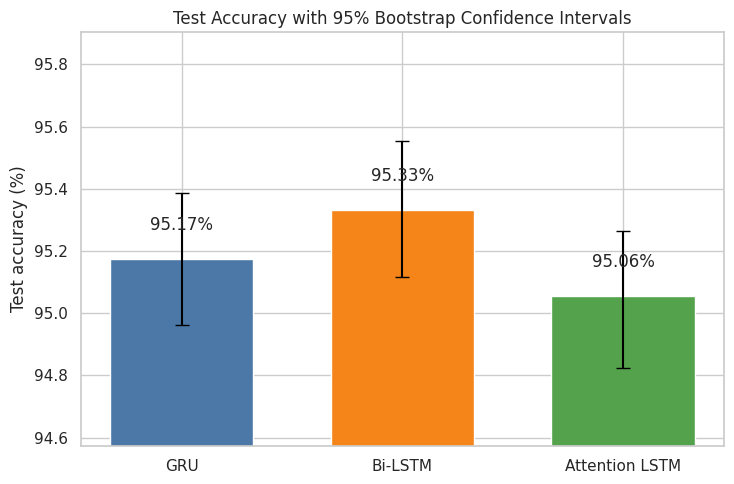

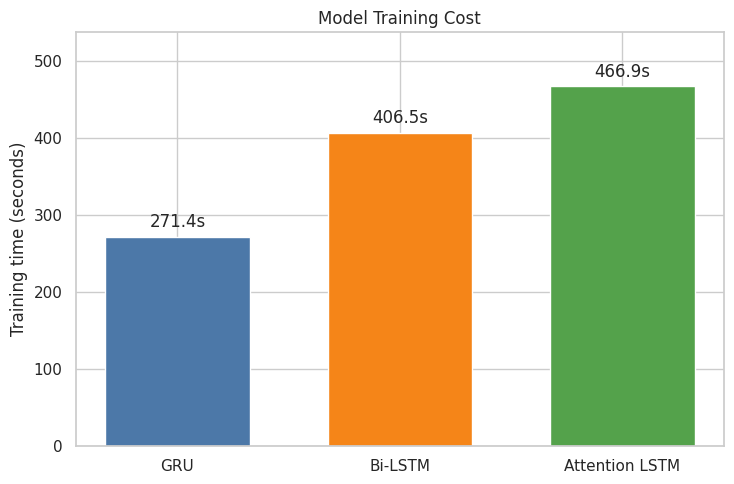

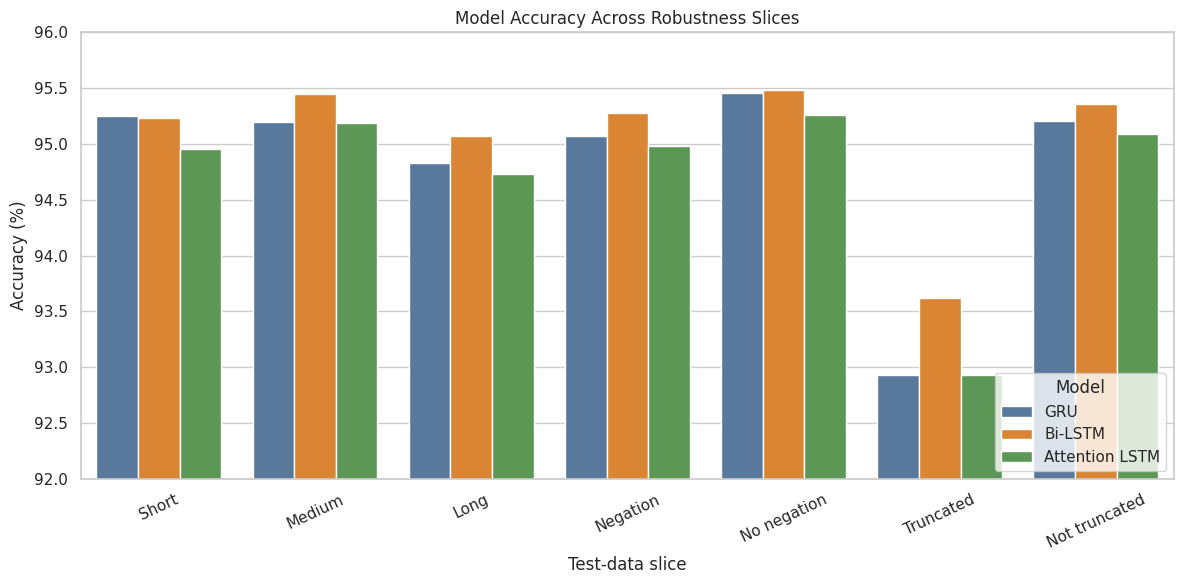

In [ ]:
# ============================================================
# STEP 39: Final model-comparison figures
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


FIGURE_OUTPUT_DIR = (
    COMPARISON_OUTPUT_DIR / "figures"
)

FIGURE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


sns.set_theme(
    style="whitegrid",
    context="notebook"
)


model_name_display = {
    "baseline_gru": "GRU",
    "bidirectional_lstm": "Bi-LSTM",
    "attention_lstm": "Attention LSTM",
}

model_colors = {
    "baseline_gru": "#4C78A8",
    "bidirectional_lstm": "#F58518",
    "attention_lstm": "#54A24B",
}


# ------------------------------------------------------------
# Figure 1: Accuracy with bootstrap confidence intervals
# ------------------------------------------------------------

accuracy_plot_data = model_comparison.copy()

accuracy_plot_data["display_name"] = (
    accuracy_plot_data["model_name"].map(
        model_name_display
    )
)

accuracy_plot_data["accuracy_percent"] = (
    accuracy_plot_data["accuracy"] * 100
)

accuracy_plot_data["lower_error"] = (
    accuracy_plot_data["accuracy"]
    - accuracy_plot_data["accuracy_ci_lower"]
) * 100

accuracy_plot_data["upper_error"] = (
    accuracy_plot_data["accuracy_ci_upper"]
    - accuracy_plot_data["accuracy"]
) * 100


fig, ax = plt.subplots(
    figsize=(7.5, 5)
)

x_positions = np.arange(
    len(accuracy_plot_data)
)

bar_colors = [
    model_colors[name]
    for name in accuracy_plot_data["model_name"]
]

ax.bar(
    x_positions,
    accuracy_plot_data["accuracy_percent"],
    color=bar_colors,
    width=0.65
)

ax.errorbar(
    x_positions,
    accuracy_plot_data["accuracy_percent"],
    yerr=[
        accuracy_plot_data["lower_error"],
        accuracy_plot_data["upper_error"],
    ],
    fmt="none",
    ecolor="black",
    capsize=5,
    linewidth=1.5
)

for index, value in enumerate(
    accuracy_plot_data["accuracy_percent"]
):
    ax.text(
        index,
        value + 0.08,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

ax.set_xticks(
    x_positions,
    accuracy_plot_data["display_name"]
)

ax.set_ylabel("Test accuracy (%)")
ax.set_title(
    "Test Accuracy with 95% Bootstrap Confidence Intervals"
)

minimum_limit = (
    accuracy_plot_data["accuracy_ci_lower"].min()
    * 100
    - 0.25
)

maximum_limit = (
    accuracy_plot_data["accuracy_ci_upper"].max()
    * 100
    + 0.35
)

ax.set_ylim(
    minimum_limit,
    maximum_limit
)

fig.tight_layout()

fig.savefig(
    FIGURE_OUTPUT_DIR
    / "accuracy_confidence_intervals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Figure 2: Training time
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7.5, 5)
)

training_times = accuracy_plot_data[
    "training_time_seconds"
]

ax.bar(
    x_positions,
    training_times,
    color=bar_colors,
    width=0.65
)

for index, value in enumerate(training_times):
    ax.text(
        index,
        value + 7,
        f"{value:.1f}s",
        ha="center",
        va="bottom"
    )

ax.set_xticks(
    x_positions,
    accuracy_plot_data["display_name"]
)

ax.set_ylabel("Training time (seconds)")
ax.set_title("Model Training Cost")

ax.set_ylim(
    0,
    training_times.max() * 1.15
)

fig.tight_layout()

fig.savefig(
    FIGURE_OUTPUT_DIR
    / "training_time_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Figure 3: Accuracy by robustness slice
# ------------------------------------------------------------

slice_plot_data = all_slice_metrics.copy()

slice_plot_data["display_name"] = (
    slice_plot_data["model_name"].map(
        model_name_display
    )
)

slice_plot_data["accuracy_percent"] = (
    slice_plot_data["accuracy"] * 100
)

slice_label_display = {
    "short_1_to_32": "Short",
    "medium_33_to_128": "Medium",
    "long_129_to_256": "Long",
    "contains_negation": "Negation",
    "no_negation": "No negation",
    "truncated": "Truncated",
    "not_truncated": "Not truncated",
}

slice_plot_data["slice_display"] = (
    slice_plot_data["slice_name"].map(
        slice_label_display
    )
)

slice_order = [
    "Short",
    "Medium",
    "Long",
    "Negation",
    "No negation",
    "Truncated",
    "Not truncated",
]


fig, ax = plt.subplots(
    figsize=(12, 6)
)

sns.barplot(
    data=slice_plot_data,
    x="slice_display",
    y="accuracy_percent",
    hue="display_name",
    order=slice_order,
    hue_order=[
        "GRU",
        "Bi-LSTM",
        "Attention LSTM",
    ],
    palette=[
        model_colors["baseline_gru"],
        model_colors["bidirectional_lstm"],
        model_colors["attention_lstm"],
    ],
    ax=ax
)

ax.set_xlabel("Test-data slice")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Model Accuracy Across Robustness Slices")
ax.set_ylim(92, 96)

ax.tick_params(
    axis="x",
    rotation=25
)

ax.legend(
    title="Model",
    loc="lower right"
)

fig.tight_layout()

fig.savefig(
    FIGURE_OUTPUT_DIR
    / "slice_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


logger.info(
    "Final comparison figures saved to: %s",
    FIGURE_OUTPUT_DIR
)

In [ ]:
# ============================================================
# STEP 40: Select 20 required errors for manual review
# ============================================================

import numpy as np
import pandas as pd


manual_error_data = error_analysis_data.copy()

manual_error_data["model_prediction"] = (
    manual_error_data["baseline_gru_prediction"]
)

manual_error_data["probability_positive"] = (
    manual_error_data["baseline_gru_probability"]
)

manual_error_data["was_truncated"] = (
    manual_error_data["original_clean_length"]
    > MAX_SEQUENCE_LENGTH
)

manual_error_data["distance_from_threshold"] = (
    manual_error_data["probability_positive"]
    - 0.5
).abs()

manual_error_data["prediction_confidence"] = np.where(
    manual_error_data["model_prediction"] == 1,
    manual_error_data["probability_positive"],
    1 - manual_error_data["probability_positive"]
)

manual_error_data["is_error"] = (
    manual_error_data["model_prediction"]
    != manual_error_data["label"]
)


# ------------------------------------------------------------
# 1. Five confident false positives
# True label = negative, prediction = positive
# ------------------------------------------------------------

confident_false_positives = (
    manual_error_data.loc[
        (manual_error_data["label"] == 0)
        & (manual_error_data["model_prediction"] == 1)
    ]
    .sort_values(
        "probability_positive",
        ascending=False
    )
    .head(5)
    .copy()
)

confident_false_positives[
    "review_category"
] = "confident_false_positive"


# ------------------------------------------------------------
# 2. Five confident false negatives
# True label = positive, prediction = negative
# ------------------------------------------------------------

confident_false_negatives = (
    manual_error_data.loc[
        (manual_error_data["label"] == 1)
        & (manual_error_data["model_prediction"] == 0)
    ]
    .sort_values(
        "probability_positive",
        ascending=True
    )
    .head(5)
    .copy()
)

confident_false_negatives[
    "review_category"
] = "confident_false_negative"


# Keep later categories disjoint
selected_row_ids = set(
    confident_false_positives["row_id"]
).union(
    confident_false_negatives["row_id"]
)


# ------------------------------------------------------------
# 3. Five near-threshold errors
# ------------------------------------------------------------

near_threshold_errors = (
    manual_error_data.loc[
        manual_error_data["is_error"]
        & ~manual_error_data["row_id"].isin(
            selected_row_ids
        )
    ]
    .sort_values(
        "distance_from_threshold",
        ascending=True
    )
    .head(5)
    .copy()
)

near_threshold_errors[
    "review_category"
] = "near_threshold_error"

selected_row_ids.update(
    near_threshold_errors["row_id"]
)


# ------------------------------------------------------------
# 4. Five truncated-review failures
# ------------------------------------------------------------

slice_specific_failures = (
    manual_error_data.loc[
        manual_error_data["is_error"]
        & manual_error_data["was_truncated"]
        & ~manual_error_data["row_id"].isin(
            selected_row_ids
        )
    ]
    .sort_values(
        "prediction_confidence",
        ascending=False
    )
    .head(5)
    .copy()
)

slice_specific_failures[
    "review_category"
] = "truncated_review_failure"


# ------------------------------------------------------------
# 5. Combine and validate all 20 examples
# ------------------------------------------------------------

manual_error_review = pd.concat(
    [
        confident_false_positives,
        confident_false_negatives,
        near_threshold_errors,
        slice_specific_failures,
    ],
    ignore_index=True
)

assert len(manual_error_review) == 20, (
    "The manual error review must contain 20 examples."
)

assert (
    manual_error_review["row_id"].nunique() == 20
), "The selected error examples must be unique."


# Empty fields to complete after manual inspection
manual_error_review["error_type"] = ""
manual_error_review["observation"] = ""
manual_error_review["proposed_testable_fix"] = ""


# ------------------------------------------------------------
# 6. Save review template
# ------------------------------------------------------------

manual_review_columns = [
    "review_category",
    "row_id",
    "label",
    "model_prediction",
    "probability_positive",
    "prediction_confidence",
    "original_clean_length",
    "sequence_length",
    "was_truncated",
    "clean_text",
    "error_type",
    "observation",
    "proposed_testable_fix",
]

MANUAL_ERROR_REVIEW_PATH = (
    COMPARISON_OUTPUT_DIR
    / "manual_error_review_20.csv"
)

manual_error_review[
    manual_review_columns
].to_csv(
    MANUAL_ERROR_REVIEW_PATH,
    index=False
)


# ------------------------------------------------------------
# 7. Display category counts and readable excerpts
# ------------------------------------------------------------

print("Category counts:")
print(
    manual_error_review[
        "review_category"
    ].value_counts()
)

manual_error_review["review_excerpt"] = (
    manual_error_review["clean_text"]
    .str.slice(0, 400)
)

print(
    "\nSelected examples:\n"
)

print(
    manual_error_review[
        [
            "review_category",
            "row_id",
            "label",
            "model_prediction",
            "probability_positive",
            "original_clean_length",
            "review_excerpt",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)

Category counts:
review_category
confident_false_positive    5
confident_false_negative    5
near_threshold_error        5
truncated_review_failure    5
Name: count, dtype: int64

Selected examples:

         review_category  row_id  label  model_prediction  probability_positive  original_clean_length                                                                                                                                                                                                                                                                                                                                                                                                   review_excerpt
confident_false_positive   22663      0                 1                0.9997                     93 average far steakhouses rib eye very tasty but little cooked did not complain flavor fantastic thought process quite order better sell say more content want great high end steak recommend ruth 

In [ ]:
### manual error analysis

manual_annotations = {
    22663: {
        "error_type": "mixed sentiment and value conflict",
        "observation": (
            "The review praises the steak and flavor but "
            "criticizes the high price and value. Strong positive "
            "food words likely dominated the prediction."
        ),
        "proposed_testable_fix": (
            "Test clause-level mean and max pooling so praise and "
            "price complaints are represented separately."
        ),
    },
    29330: {
        "error_type": "possible annotation noise",
        "observation": (
            "The text is clearly positive, using words such as "
            "love, clean, great, relax, and worth trying, although "
            "its label is negative."
        ),
        "proposed_testable_fix": (
            "Verify the source label and row alignment. Manually "
            "audit high-confidence disagreements and retrain after "
            "removing confirmed mislabeled examples."
        ),
    },
    29525: {
        "error_type": "mixed item-level sentiment",
        "observation": (
            "The cookie is criticized, but the ice cream and part "
            "of the experience are praised. The model focused more "
            "on the positive item."
        ),
        "proposed_testable_fix": (
            "Test sentence-level or item-level pooling and compare "
            "performance on reviews discussing multiple products."
        ),
    },
    34068: {
        "error_type": "service recovery and mixed sentiment",
        "observation": (
            "The review reports several cooking failures but ends "
            "with praise for the replacement burger, manager, and "
            "service."
        ),
        "proposed_testable_fix": (
            "Test a model that combines mean pooling with the final "
            "hidden state to preserve both failures and the ending."
        ),
    },
    4488: {
        "error_type": "comparative and ambiguous sentiment",
        "observation": (
            "The reviewer calls the experience enjoyable but says "
            "other sushi restaurants are better. The overall rating "
            "is difficult to infer from the wording alone."
        ),
        "proposed_testable_fix": (
            "Add comparative-review examples to training and measure "
            "accuracy on a manually tagged comparison slice."
        ),
    },
    23763: {
        "error_type": "aspect conflict",
        "observation": (
            "The market and products are praised, but customer "
            "service receives extensive criticism. The model focused "
            "on the longer negative service section."
        ),
        "proposed_testable_fix": (
            "Test aspect-aware sentence pooling and measure errors "
            "on reviews containing both product and service opinions."
        ),
    },
    27334: {
        "error_type": "product-service sentiment conflict",
        "observation": (
            "The product is described as brilliant, while staff, "
            "service, and atmosphere are strongly criticized."
        ),
        "proposed_testable_fix": (
            "Separate product and service clauses before pooling and "
            "compare macro-F1 on mixed-aspect reviews."
        ),
    },
    22807: {
        "error_type": "temporal update conflict",
        "observation": (
            "The reviewer mentions that this used to be a favorite "
            "place but then describes a recent negative incident."
        ),
        "proposed_testable_fix": (
            "Test additional weighting for later clauses and explicit "
            "update markers such as edit, now, and used to."
        ),
    },
    22451: {
        "error_type": "possible annotation noise",
        "observation": (
            "The text is overwhelmingly negative and includes food "
            "quality and illness complaints, although the saved label "
            "is positive."
        ),
        "proposed_testable_fix": (
            "Verify the original dataset label and preprocessing "
            "join. Remove or relabel the example only if a source-data "
            "audit confirms an error."
        ),
    },
    9477: {
        "error_type": "sarcasm and long humorous narrative",
        "observation": (
            "The review uses insults, profanity, and exaggerated "
            "humor. These surface cues appear negative even though "
            "the assigned label is positive."
        ),
        "proposed_testable_fix": (
            "Create a sarcasm and humor slice, then test whether "
            "character n-gram features or a CNN-GRU model improves it."
        ),
    },
    37072: {
        "error_type": "mixed sentiment with decisive complaint",
        "observation": (
            "The review lists several food strengths but later "
            "describes stomach cramps and misleading information."
        ),
        "proposed_testable_fix": (
            "Test sentence-level pooling that gives more weight to "
            "strong health and safety complaints."
        ),
    },
    17235: {
        "error_type": "food-service aspect conflict",
        "observation": (
            "The food is called excellent, but the service and "
            "atmosphere are criticized. The probability near 0.5 "
            "shows that the model detected both sides."
        ),
        "proposed_testable_fix": (
            "Evaluate separate food and service representations and "
            "combine them with a learned classification layer."
        ),
    },
    2971: {
        "error_type": "short implicit complaint",
        "observation": (
            "The review does not use many direct negative words. Its "
            "complaint is implied by little chicken and excessive "
            "batter."
        ),
        "proposed_testable_fix": (
            "Test a CNN-GRU model with local phrase filters and "
            "compare results on short-review errors."
        ),
    },
    4769: {
        "error_type": "narrative review with unclear verdict",
        "observation": (
            "Much of the text describes the restaurant's history and "
            "pizza rather than stating a direct opinion. The decisive "
            "sentiment is difficult to locate."
        ),
        "proposed_testable_fix": (
            "Test sentence-level attention and inspect whether it "
            "focuses on evaluative rather than background sentences."
        ),
    },
    23218: {
        "error_type": "temporal sentiment reversal",
        "observation": (
            "The review first praises the radio station but an update "
            "says its format changed and is now disliked."
        ),
        "proposed_testable_fix": (
            "Preserve update markers and test recency-weighted pooling "
            "that emphasizes later review content."
        ),
    },
    20061: {
        "error_type": "truncation and delayed sentiment",
        "observation": (
            "The retained beginning is a long narrative containing "
            "negative-sounding waste and garbage terms. The decisive "
            "positive assessment may occur after the token limit."
        ),
        "proposed_testable_fix": (
            "Compare first-256 truncation with head-tail truncation "
            "using the first 128 and final 128 tokens."
        ),
    },
    17407: {
        "error_type": "truncation after early praise",
        "observation": (
            "The beginning contains many positive descriptions of "
            "food and service, while the negative conclusion may be "
            "outside the retained sequence."
        ),
        "proposed_testable_fix": (
            "Test head-tail truncation and compare macro-F1 and error "
            "rate specifically on truncated reviews."
        ),
    },
    32890: {
        "error_type": "truncation and mixed beer review",
        "observation": (
            "The visible section mentions a wide beer selection but "
            "also complains about prices. Later negative evidence may "
            "have been removed."
        ),
        "proposed_testable_fix": (
            "Test head-tail truncation and increase sequence length "
            "to 384 in a controlled experiment."
        ),
    },
    10881: {
        "error_type": "truncation after positive setup",
        "observation": (
            "The retained opening presents dim sum as cheap, easy, "
            "and desirable. Information explaining the negative label "
            "may appear later."
        ),
        "proposed_testable_fix": (
            "Compare first-only truncation against head-tail sampling "
            "on the same trained architecture."
        ),
    },
    1256: {
        "error_type": "truncation and delayed criticism",
        "observation": (
            "The visible beginning discusses the atmosphere and menu "
            "in mostly neutral or positive language. The negative "
            "judgment may occur beyond the retained tokens."
        ),
        "proposed_testable_fix": (
            "Use head-tail truncation and test whether truncated-slice "
            "accuracy improves over the current 92.93 percent."
        ),
    },
}


# ------------------------------------------------------------
# Apply annotations by row ID
# ------------------------------------------------------------

for row_id, annotation in manual_annotations.items():
    row_mask = (
        manual_error_review["row_id"] == row_id
    )

    assert row_mask.sum() == 1, (
        f"Expected exactly one row for row_id {row_id}."
    )

    for column_name, value in annotation.items():
        manual_error_review.loc[
            row_mask,
            column_name
        ] = value


# Confirm that every required field is complete
required_analysis_columns = [
    "error_type",
    "observation",
    "proposed_testable_fix",
]

assert not (
    manual_error_review[
        required_analysis_columns
    ].eq("").any().any()
), "Some manual-analysis fields are still empty."


# Save the completed analysis
COMPLETED_ERROR_REVIEW_PATH = (
    COMPARISON_OUTPUT_DIR
    / "manual_error_review_20_completed.csv"
)

manual_error_review[
    manual_review_columns
].to_csv(
    COMPLETED_ERROR_REVIEW_PATH,
    index=False
)


print(
    manual_error_review[
        [
            "review_category",
            "row_id",
            "error_type",
            "observation",
            "proposed_testable_fix",
        ]
    ].to_string(index=False)
)

print(
    "\nCompleted error review saved to:",
    COMPLETED_ERROR_REVIEW_PATH
)

         review_category  row_id                              error_type                                                                                                                                                        observation                                                                                                                             proposed_testable_fix
confident_false_positive   22663      mixed sentiment and value conflict                       The review praises the steak and flavor but criticizes the high price and value. Strong positive food words likely dominated the prediction.                                                 Test clause-level mean and max pooling so praise and price complaints are represented separately.
confident_false_positive   29330               possible annotation noise                                     The text is clearly positive, using words such as love, clean, great, relax, and worth trying, although its label is negative. 

In [ ]:
# ============================================================
# Save current hardware and environment information
# ============================================================

import json
import platform
import sys
import torch
import numpy as np
import pandas as pd
import sklearn


def get_cpu_name():
    try:
        with open(
            "/proc/cpuinfo",
            "r",
            encoding="utf-8"
        ) as file:
            for line in file:
                if line.lower().startswith("model name"):
                    return line.split(":", 1)[1].strip()
    except OSError:
        pass

    return platform.processor() or "unknown"


runtime_manifest = {
    "cpu": get_cpu_name(),
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else "CPU only"
    ),
    "gpu_memory_gb": (
        round(
            torch.cuda.get_device_properties(
                0
            ).total_memory / 1024**3,
            2
        )
        if torch.cuda.is_available()
        else None
    ),
    "python_version": sys.version,
    "pytorch_version": torch.__version__,
    "cuda_version": torch.version.cuda,
    "cudnn_version": (
        torch.backends.cudnn.version()
        if torch.cuda.is_available()
        else None
    ),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "scikit_learn_version": sklearn.__version__,
    "device_used_for_all_models": str(device),
}

RUNTIME_MANIFEST_PATH = (
    FOLDERS["config"] / "runtime_manifest.json"
)

with open(
    RUNTIME_MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        runtime_manifest,
        file,
        indent=4
    )

print(
    json.dumps(
        runtime_manifest,
        indent=4
    )
)

{
    "cpu": "Intel(R) Xeon(R) CPU @ 2.20GHz",
    "gpu": "NVIDIA L4",
    "gpu_memory_gb": 22.03,
    "python_version": "3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]",
    "pytorch_version": "2.11.0+cu130",
    "cuda_version": "13.0",
    "cudnn_version": 92700,
    "numpy_version": "2.1.3",
    "pandas_version": "2.2.3",
    "scikit_learn_version": "1.6.1",
    "device_used_for_all_models": "cuda"
}
